In [1]:
%load_ext autoreload
%autoreload 2
#import qRegNN_NFs as qrnn
#from trainingTools_QR import NFTrainer
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append("/home/sambt/CASE_final/CASE_QUAK_final/commonTools/")
import helper_functions as hf
import qRegNN_NFs_general as qrnn
import sklearn
import scipy
import sklearn.datasets as datasets
import h5py
import os
import pandas as pd
import corner
from sklearn.model_selection import train_test_split
sys.path.append("/home/sambt/SINF/")
sys.path.append("/home/sambt/SINF/sinf/")
from GIS import GIS
import torch
import torch.nn as nn
device = torch.device('cuda:0')

In [2]:
base = "/nobackup/users/sambt/QR_samples/jeff_pythia_vs_herwig/mar20/h5s/mar20-GRAPH/"
jtypes = []
variations = []
features = []
kinematics = []
for f in [l for l in os.listdir(base) if ".h5" in l]:
    with h5py.File(f"{base}/{f}","r") as f:
        jtypes.append(f['jet_type'][()][:,0])
        variations.append(f['jet_vartype'][()][:,0])
        features.append(f['jet_features'][()])
        kinematics.append(f['jet_kinematics'][()])
jtypes = np.concatenate(jtypes,axis=0)
variations = np.concatenate(variations,axis=0)
features = np.concatenate(features,axis=0)
kinematics = np.concatenate(kinematics,axis=0)
kin_names = ['pt','eta','phi','E',"msd","N2"]
embed_names = [f"embed_{k}" for k in range(8)]

In [3]:
class SampleContainer:
    def __init__(self,jtypes,variations,features,kinematics):
        self.jtypes = jtypes
        self.variations = variations
        self.features = features
        self.kinematics = kinematics
        self.type_key = {
            1:"l",
            2:"c",
            3:"b",
            4:"Hbb",
            5:"gll",
            6:"gcc",
            7:"gbb",
            8:"ggg"
        }
        self.key_type = {self.type_key[k]:k for k in self.type_key.keys()}
        self.var_key = {
            -1:"nom",
            0:"reseed",
            1:"FSRup",
            2:"FSRdown",
            3:"herwig"
        }
        self.key_var = {self.var_key[k]:k for k in self.var_key.keys()}
        self.kin_names = ['pt','eta','phi','E',"msd","N2"]
        self.embed_names = [f"embed_{k}" for k in range(8)]
        
    def get_pair_idx(self,sample,variation):
        samp_indices = np.argwhere(self.jtypes == self.key_type[sample])[:,0]
        nom_indices = samp_indices[self.variations[samp_indices]==-1]
        sel_indices = nom_indices[self.variations[nom_indices+1]==self.key_var[variation]]
        
        nom_idx = sel_indices
        aug_idx = sel_indices+1
        
        return nom_idx, aug_idx
    
    def get_pair(self,sample,variation):
        nom_idx, aug_idx = self.get_pair_idx(sample,variation)
        
        nom_data = [self.jtypes[nom_idx], self.variations[nom_idx], self.features[nom_idx], self.kinematics[nom_idx]]
        aug_data = [self.jtypes[aug_idx], self.variations[aug_idx], self.features[aug_idx], self.kinematics[aug_idx]]
        
        return nom_data, aug_data
    
    def get_multiPair(self,samples,variation):
        nom_datas = []
        aug_datas = []
        for samp in samples:
            nom_data,aug_data = self.get_pair(samp,variation)
            nom_datas.append(nom_data)
            aug_datas.append(aug_data)
        nom_datas = [np.concatenate([nom_datas[j][k] for j in range(len(samples))]) for k in range(len(nom_datas[0]))]
        aug_datas = [np.concatenate([aug_datas[j][k] for j in range(len(samples))]) for k in range(len(aug_datas[0]))]
        for nd in nom_datas:
            np.random.shuffle(nd)
        for ad in aug_datas:
            np.random.shuffle(ad)
        return nom_datas, aug_datas

In [4]:
container = SampleContainer(jtypes,variations,features,kinematics)

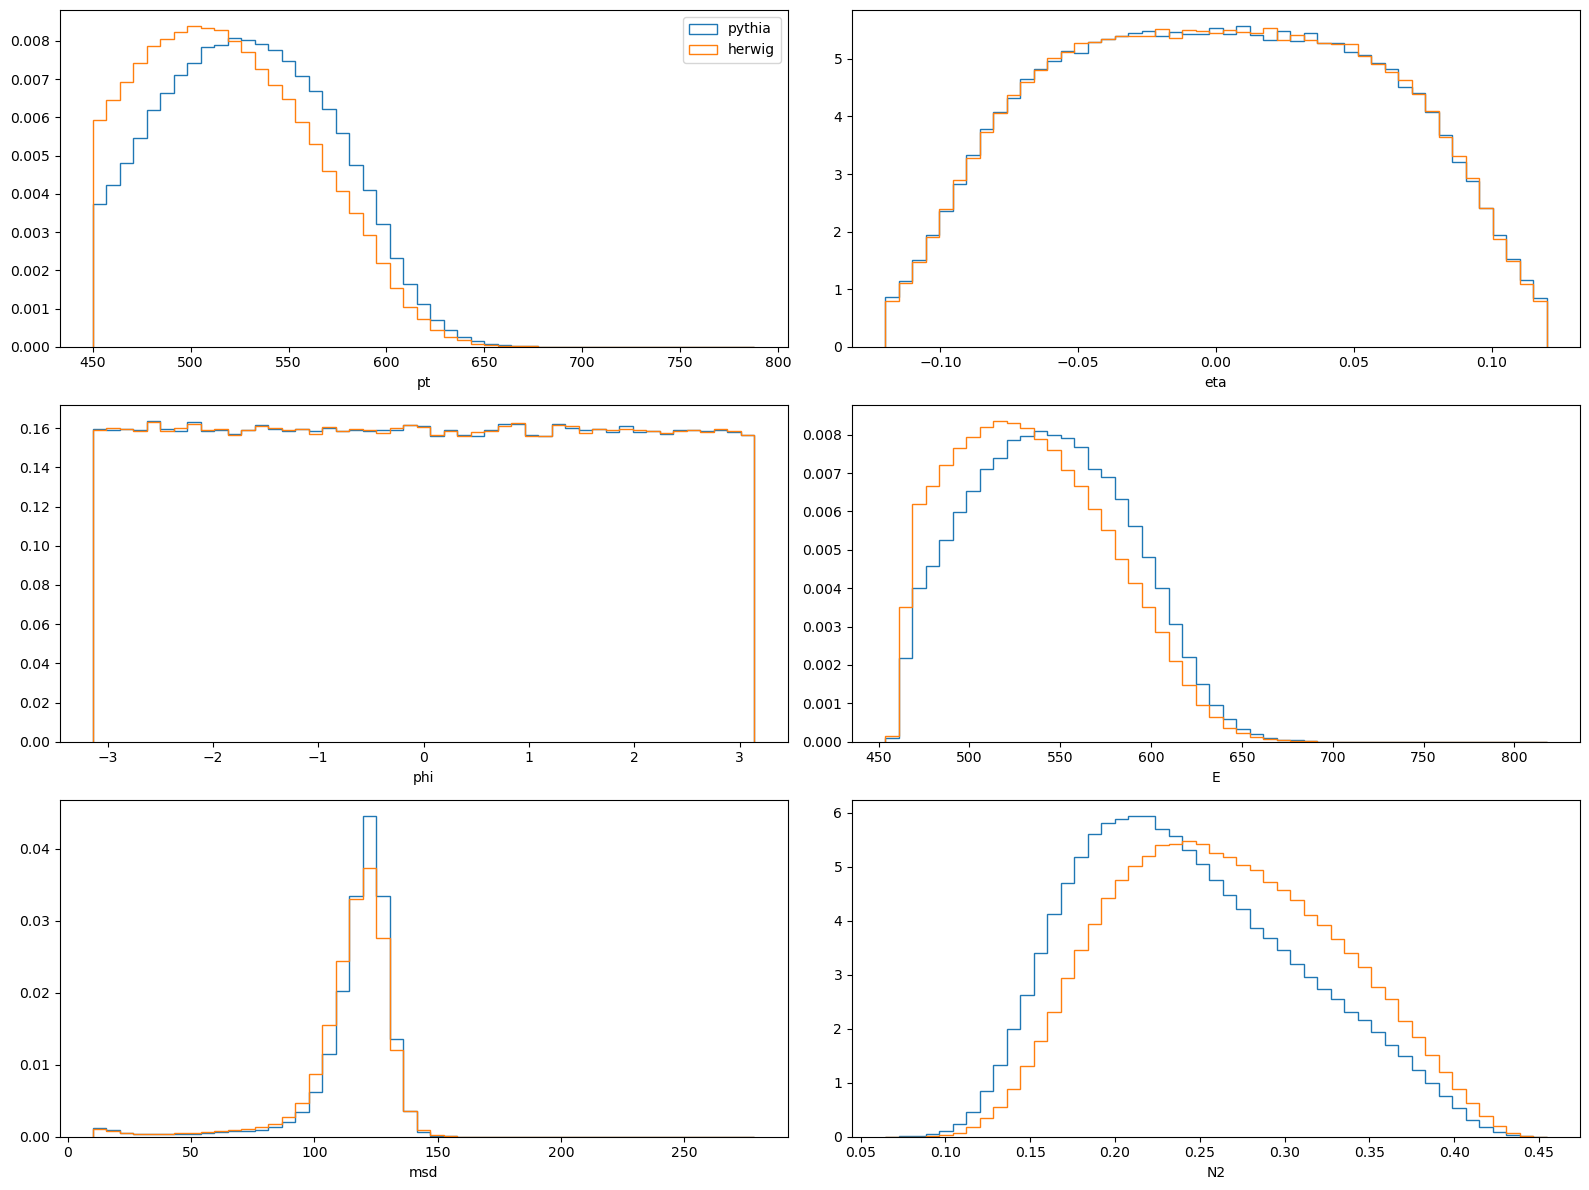

In [8]:
# compare pythia vs herwig for Hbb
pyth,herw = container.get_pair("Hbb","herwig")
kin_pyth = pyth[3]
kin_herw = herw[3]

fig,axes = plt.subplots(3,2,figsize=(16,12))
for i in range(len(kin_names)):
    plt.sca(axes.flatten()[i])
    xmin = min(kin_pyth[:,i].min(),kin_herw[:,i].min())
    xmax = max(kin_pyth[:,i].max(),kin_herw[:,i].max())
    bins = np.linspace(xmin,xmax,50)
    h1,bins,_ = plt.hist(kin_pyth[:,i],color='C0',label='pythia',density=True,bins=bins,histtype='step')
    h2,bins,_ = plt.hist(kin_herw[:,i],color='C1',label='herwig',density=True,bins=bins,histtype='step')
    plt.xlabel(kin_names[i])
    if i==0:
        plt.legend()
plt.tight_layout()

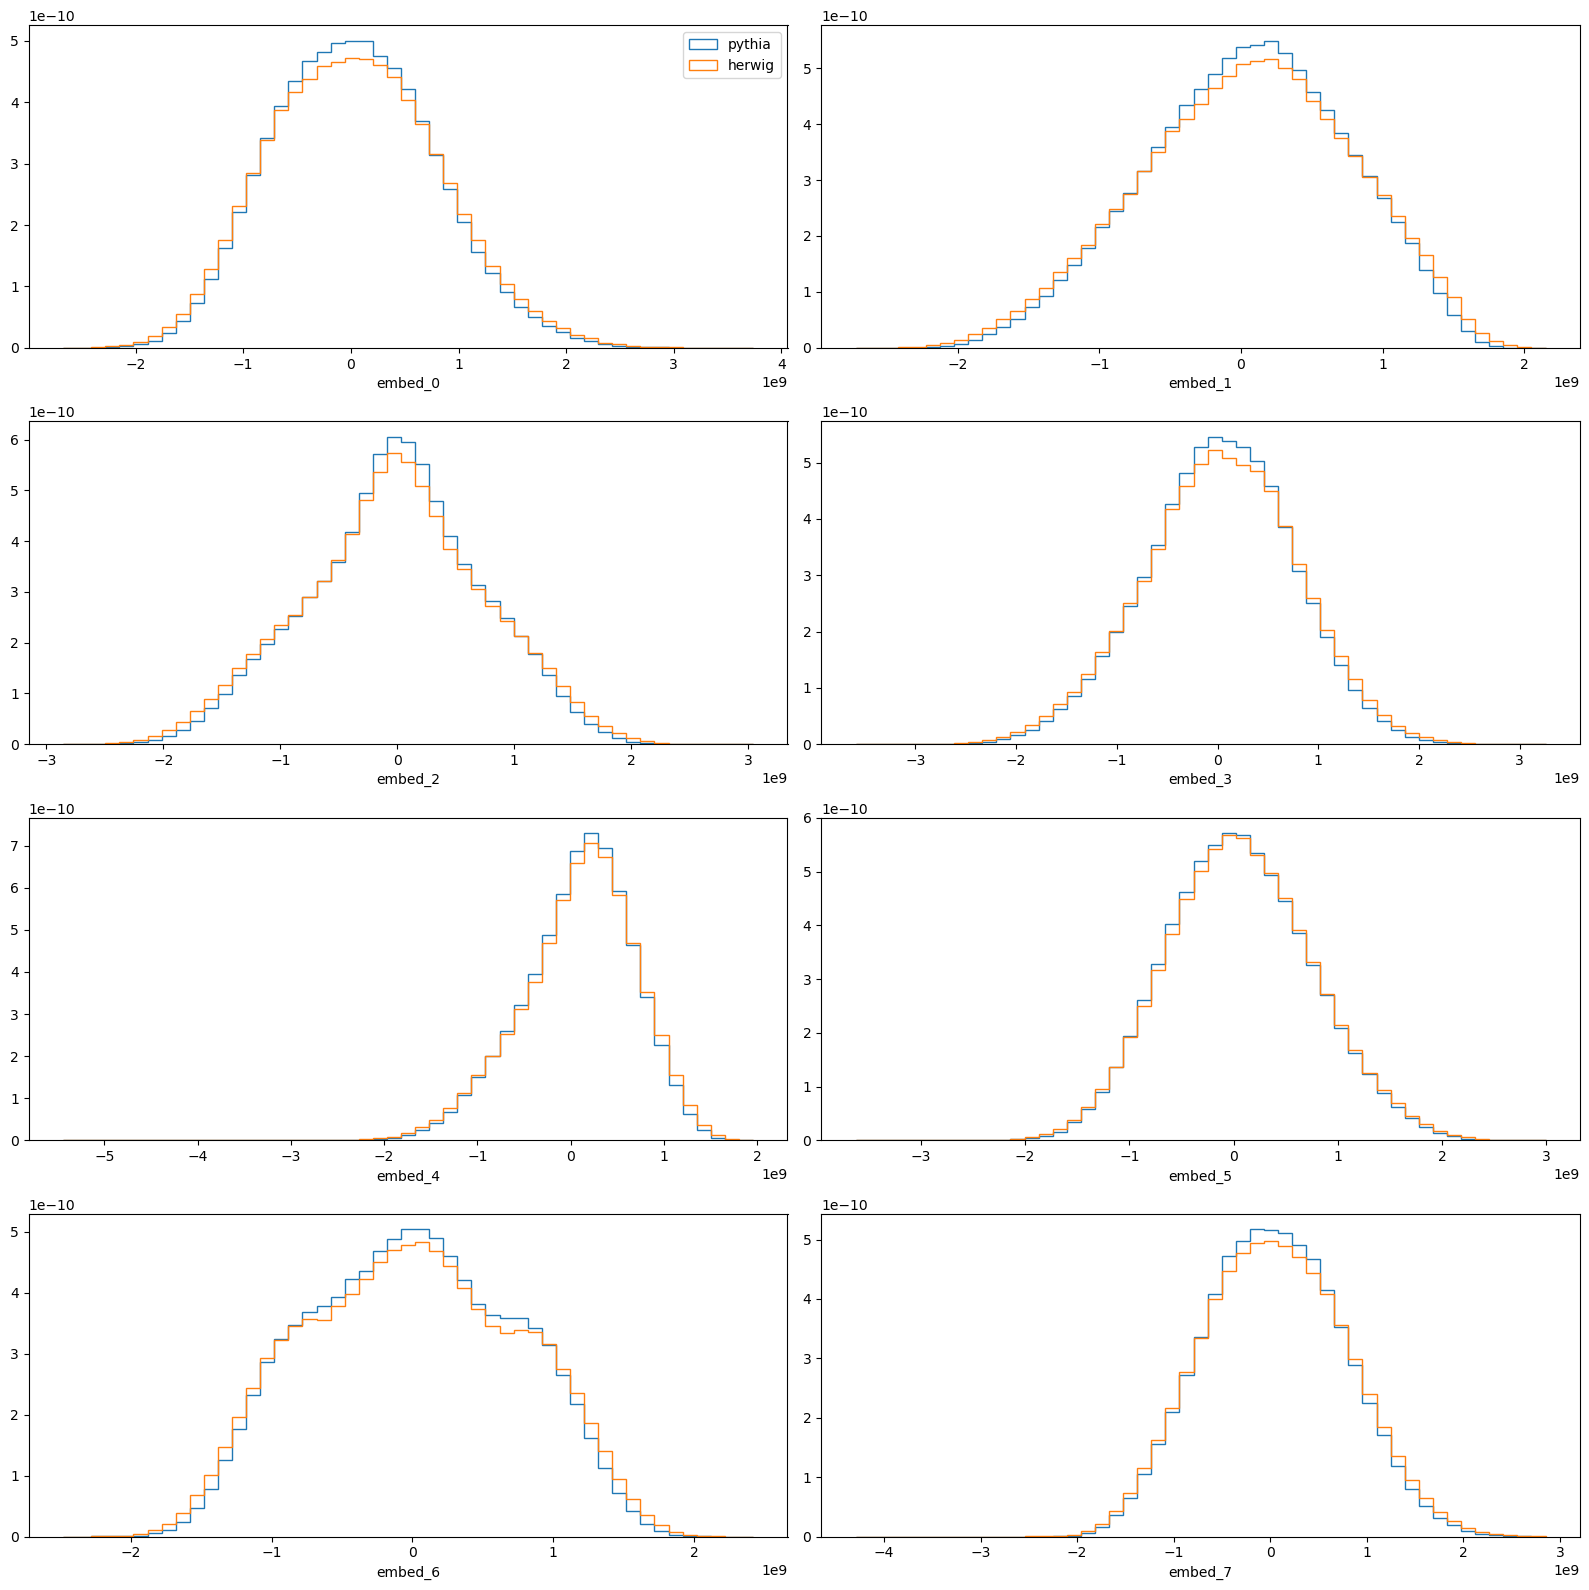

In [6]:
# compare pythia vs herwig in embedded features, Hbb
pyth,herw = container.get_pair("Hbb","herwig")
feat_pyth = pyth[2]
feat_herw = herw[2]

fig,axes = plt.subplots(4,2,figsize=(16,16))
for i in range(len(embed_names)):
    plt.sca(axes.flatten()[i])
    xmin = min(feat_pyth[:,i].min(),feat_herw[:,i].min())
    xmax = max(feat_pyth[:,i].max(),feat_herw[:,i].max())
    bins = np.linspace(xmin,xmax,50)
    h1,bins,_ = plt.hist(feat_pyth[:,i],color='C0',label='pythia',density=True,bins=bins,histtype='step')
    h2,bins,_ = plt.hist(feat_herw[:,i],color='C1',label='herwig',density=True,bins=bins,histtype='step')
    plt.xlabel(embed_names[i])
    if i==0:
        plt.legend()
plt.tight_layout()

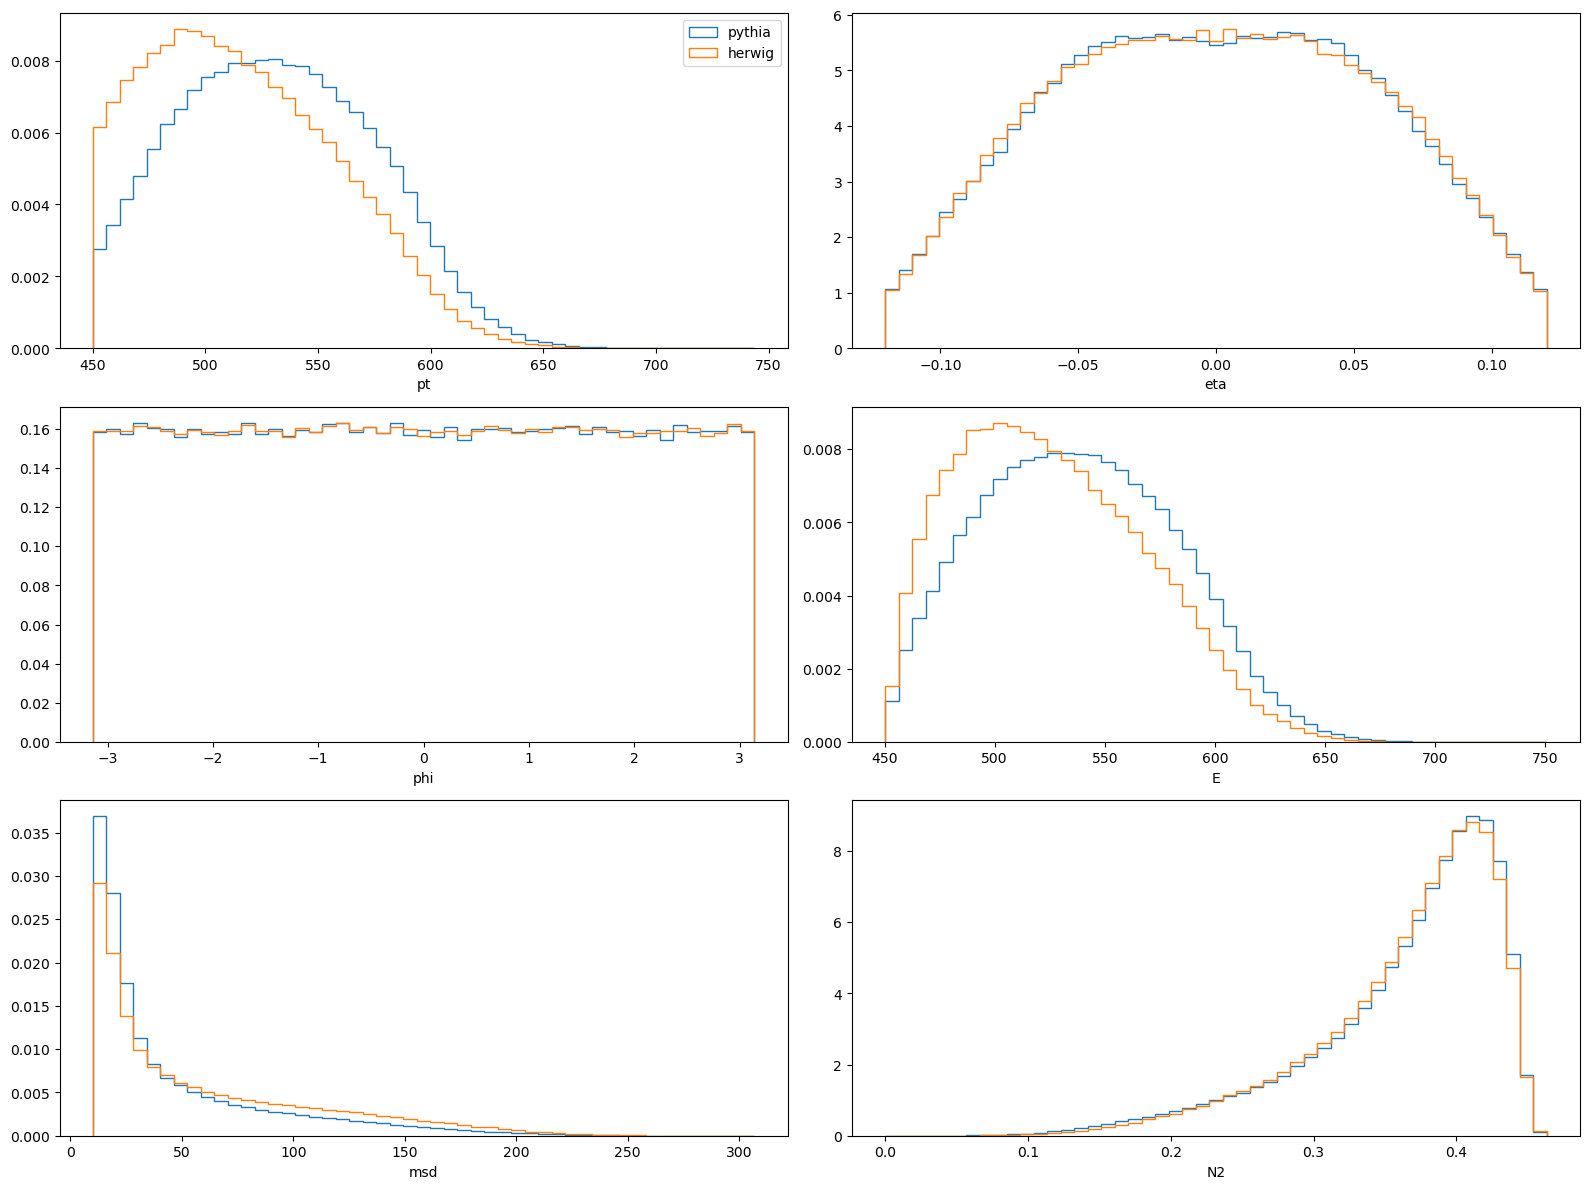

In [7]:
# compare pythia vs herwig for QCD
pyth,herw = container.get_multiPair(['l','c','b','gll','gcc','gbb','ggg'],"herwig")
kin_pyth = pyth[3]
kin_herw = herw[3]

fig,axes = plt.subplots(3,2,figsize=(16,12))
for i in range(len(kin_names)):
    plt.sca(axes.flatten()[i])
    xmin = min(kin_pyth[:,i].min(),kin_herw[:,i].min())
    xmax = max(kin_pyth[:,i].max(),kin_herw[:,i].max())
    bins = np.linspace(xmin,xmax,50)
    h1,bins,_ = plt.hist(kin_pyth[:,i],color='C0',label='pythia',density=True,bins=bins,histtype='step')
    h2,bins,_ = plt.hist(kin_herw[:,i],color='C1',label='herwig',density=True,bins=bins,histtype='step')
    plt.xlabel(kin_names[i])
    if i==0:
        plt.legend()
plt.tight_layout()

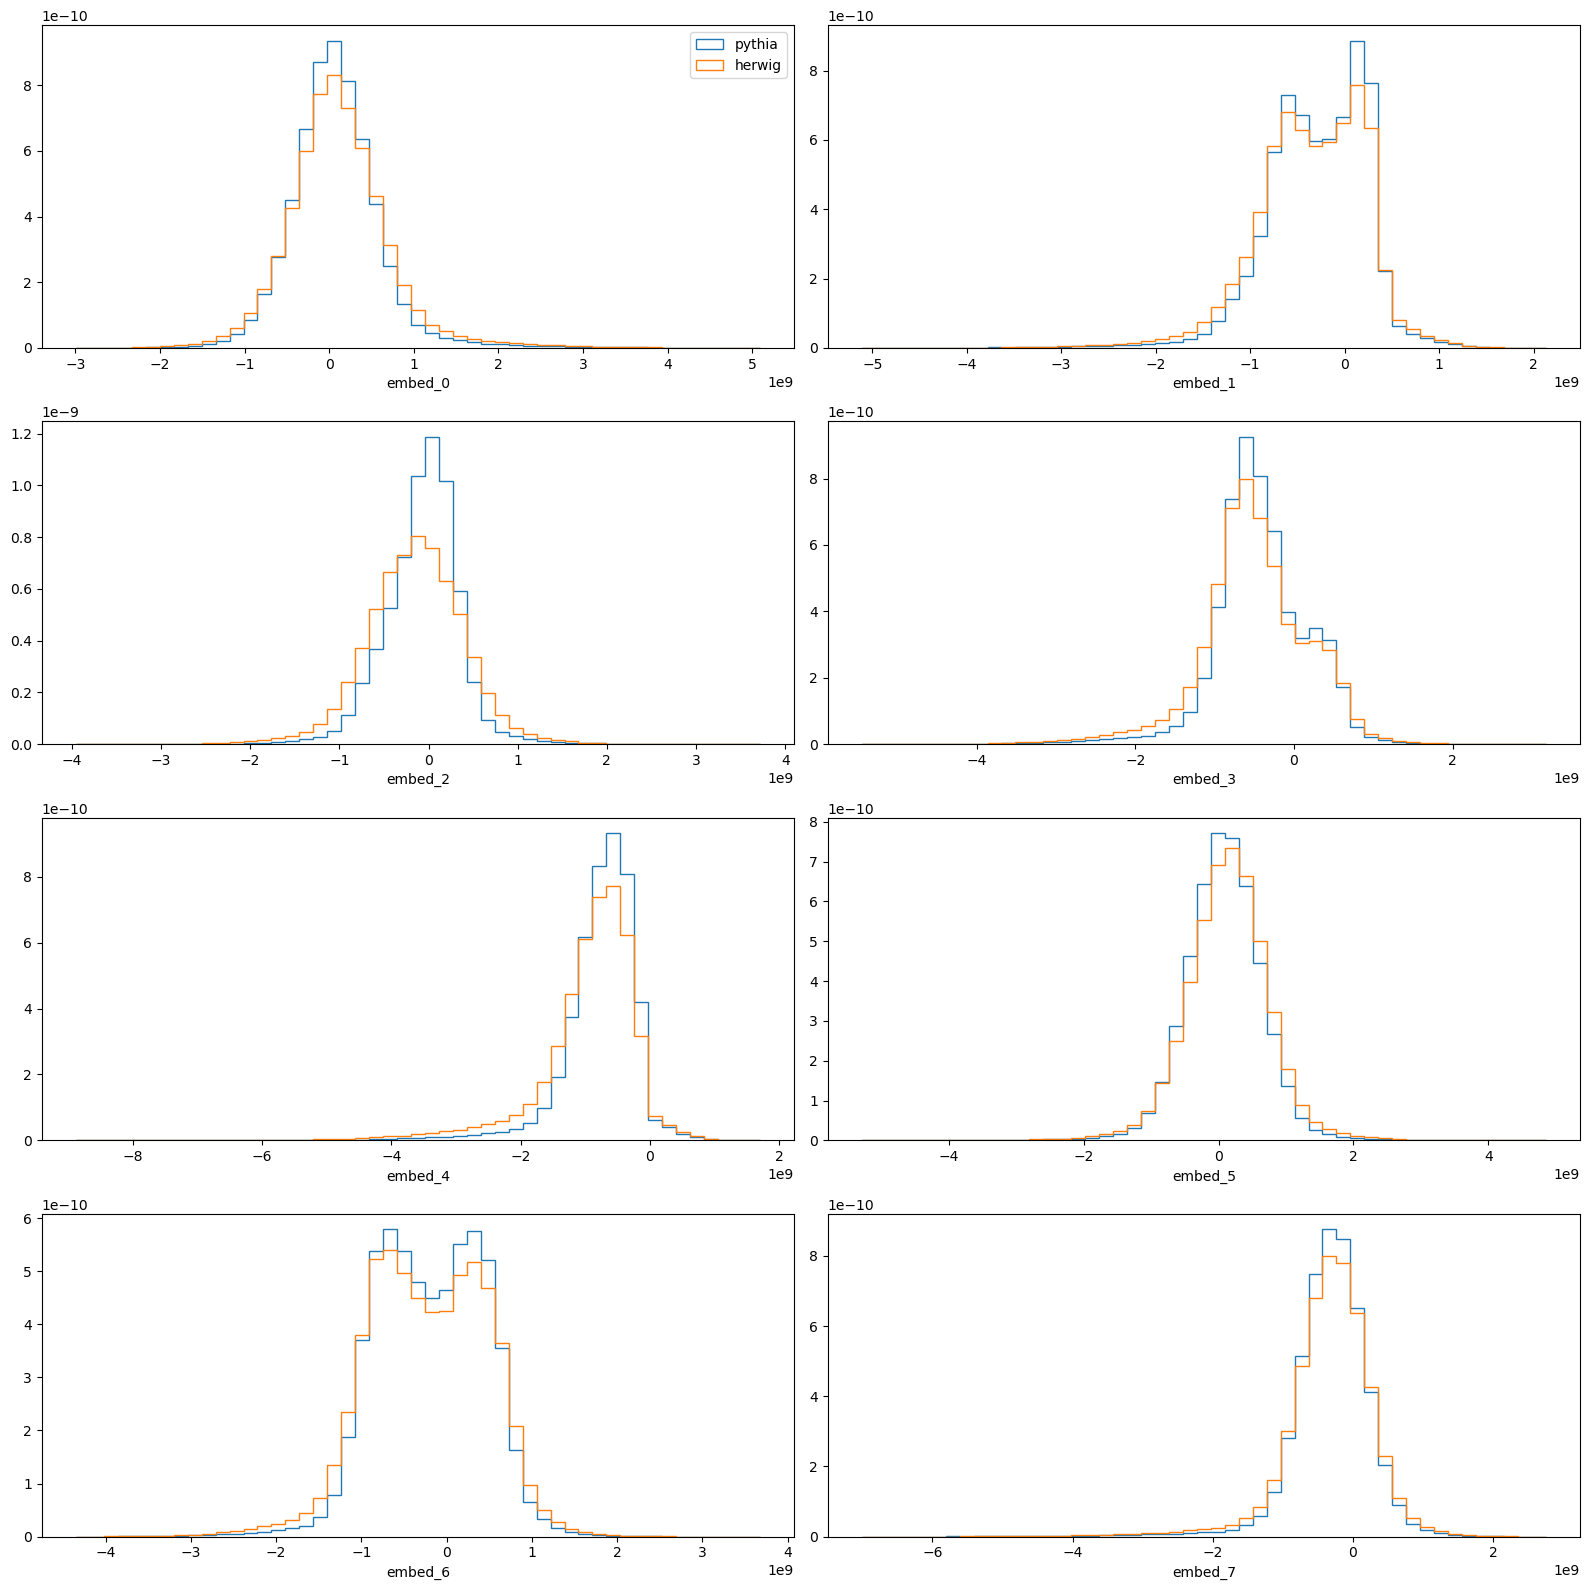

In [8]:
# compare pythia vs herwig in embedded features, QCD
pyth,herw = container.get_multiPair(['l','c','b','gll','gcc','gbb','ggg'],"herwig")
feat_pyth = pyth[2]
feat_herw = herw[2]

fig,axes = plt.subplots(4,2,figsize=(16,16))
for i in range(len(embed_names)):
    plt.sca(axes.flatten()[i])
    xmin = min(feat_pyth[:,i].min(),feat_herw[:,i].min())
    xmax = max(feat_pyth[:,i].max(),feat_herw[:,i].max())
    bins = np.linspace(xmin,xmax,50)
    h1,bins,_ = plt.hist(feat_pyth[:,i],color='C0',label='pythia',density=True,bins=bins,histtype='step')
    h2,bins,_ = plt.hist(feat_herw[:,i],color='C1',label='herwig',density=True,bins=bins,histtype='step')
    plt.xlabel(embed_names[i])
    if i==0:
        plt.legend()
plt.tight_layout()

# Correct herwig --> pythia in contrastive space; QCD

In [5]:
pyth,herw = container.get_multiPair(['l','c','b','gll','gcc','gbb','ggg'],"herwig")
feat_pyth = pyth[2]
feat_herw = herw[2]

feat_pyth = (feat_pyth-feat_pyth.mean(axis=0))/feat_pyth.std(axis=0)
feat_herw = (feat_herw-feat_herw.mean(axis=0))/feat_herw.std(axis=0)

pyth_train, pyth_test = train_test_split(feat_pyth, test_size=0.5, random_state=48572)
herw_train, herw_test = train_test_split(feat_herw, test_size=0.5, random_state=98113)

In [6]:
flow_pyth = torch.load("NF_models_QR_general/HerwigToPythia_contrastiveSpace_qcd/flow0_pyth_GIS_embed0.pt").to(device)
flow_herw = torch.load("NF_models_QR_general/HerwigToPythia_contrastiveSpace_qcd/flow0_herw_GIS_embed0.pt").to(device)

In [7]:
with torch.no_grad():
    noise_train = flow_herw(torch.tensor(herw_train[:,:1],device=device,dtype=torch.float32))[0]
    corr_train = flow_pyth.inverse(noise_train)[0].detach().cpu().numpy()
    noise_test = flow_herw(torch.tensor(herw_test[:,:1],device=device,dtype=torch.float32))[0]
    corr_test = flow_pyth.inverse(noise_test)[0].detach().cpu().numpy()
herw2_train = np.copy(herw_train)
herw2_train[:,0] = corr_train[:,0]
herw2_test = np.copy(herw_test)
herw2_test[:,0] = corr_test[:,0]

In [6]:
flow_pyth = GIS(torch.tensor(pyth_train[:,:1],dtype=torch.float32,device=device), 
           torch.tensor(pyth_test[:,:1],dtype=torch.float32,device=device), 
            Whiten=True, 
            batchsize=50000, 
            nocuda=False,
           edge_bins=5,
            M=30,
            K=1,
           iteration=1000,
            verbose=True)

/home/sambt/SINF/sinf/SINF.py:291: UserWarning: torch.symeig is deprecated in favor of torch.linalg.eigh and will be removed in a future PyTorch release.
The default behavior has changed from using the upper triangular portion of the matrix by default to using the lower triangular portion.
L, _ = torch.symeig(A, upper=upper)
should be replaced with
L = torch.linalg.eigvalsh(A, UPLO='U' if upper else 'L')
and
L, V = torch.symeig(A, eigenvectors=True)
should be replaced with
L, V = torch.linalg.eigh(A, UPLO='U' if upper else 'L') (Triggered internally at  /data/florin/opence-conda-bld/pytorch-base_1633177744875/work/aten/src/ATen/native/BatchLinearAlgebra.cpp:2500.)
  D, E = torch.symeig(covariance, eigenvectors=True)


After whiten logp: -1.4211639165878296 -1.4168815612792969


/home/sambt/SINF/sinf/SINF.py:494: UserWarning: torch.qr is deprecated in favor of torch.linalg.qr and will be removed in a future PyTorch release.
The boolean parameter 'some' has been replaced with a string parameter 'mode'.
Q, R = torch.qr(A, some)
should be replaced with
Q, R = torch.linalg.qr(A, 'reduced' if some else 'complete') (Triggered internally at  /data/florin/opence-conda-bld/pytorch-base_1633177744875/work/aten/src/ATen/native/BatchLinearAlgebra.cpp:1940.)
  Q, R = torch.qr(ATi)


Fit spline Time: 0.015983712196350097
logp: -1.4092578887939453 -1.4053044319152832 time: 2.5065109729766846 iteration: 2 best: 2
Fit spline Time: 0.015215616226196289
logp: -1.3994368314743042 -1.3957743644714355 time: 0.048120737075805664 iteration: 3 best: 3
Fit spline Time: 0.015114239692687988
logp: -1.3913204669952393 -1.387915849685669 time: 0.047883033752441406 iteration: 4 best: 4
Fit spline Time: 0.015046655654907226
logp: -1.384603500366211 -1.3814278841018677 time: 0.048026084899902344 iteration: 5 best: 5
Fit spline Time: 0.016647167205810547
logp: -1.3790358304977417 -1.3760638236999512 time: 0.0524141788482666 iteration: 6 best: 6
Fit spline Time: 0.015108096122741698
logp: -1.3744146823883057 -1.371624231338501 time: 0.04812169075012207 iteration: 7 best: 7
Fit spline Time: 0.015073280334472656
logp: -1.3705742359161377 -1.3679461479187012 time: 0.04786252975463867 iteration: 8 best: 8
Fit spline Time: 0.015034367561340332
logp: -1.3673779964447021 -1.3648948669433594 t

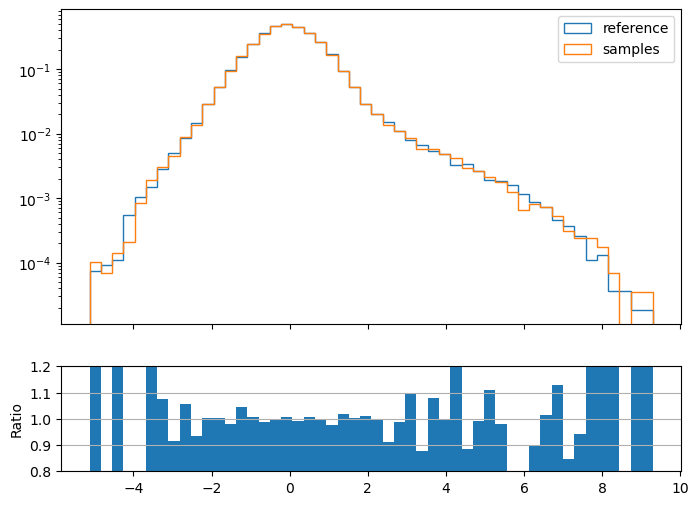

In [8]:
with torch.no_grad():
    samples = flow_pyth.sample(100000)[0].detach().cpu().numpy()
qrnn.plotPair(pyth_test[:,0],samples[:,0],log=True)

In [9]:
flow_herw = GIS(torch.tensor(herw_train[:,:1],dtype=torch.float32,device=device), 
           torch.tensor(herw_test[:,:1],dtype=torch.float32,device=device), 
            Whiten=True, 
            batchsize=50000, 
            nocuda=False,
           edge_bins=5,
            M=30,
            K=1,
           iteration=1000,
            verbose=True)

After whiten logp: -1.420854926109314 -1.4171568155288696
Fit spline Time: 0.016262144088745118
logp: -1.4091269969940186 -1.4055248498916626 time: 0.05643749237060547 iteration: 2 best: 2
Fit spline Time: 0.01719500732421875
logp: -1.3995122909545898 -1.3959929943084717 time: 0.05484127998352051 iteration: 3 best: 3
Fit spline Time: 0.015772671699523927
logp: -1.3916194438934326 -1.388171911239624 time: 0.04957008361816406 iteration: 4 best: 4
Fit spline Time: 0.015150079727172852
logp: -1.3851332664489746 -1.3817481994628906 time: 0.051346540451049805 iteration: 5 best: 5
Fit spline Time: 0.01520844841003418
logp: -1.379798173904419 -1.3764674663543701 time: 0.04930448532104492 iteration: 6 best: 6
Fit spline Time: 0.015131648063659669
logp: -1.37540602684021 -1.3721230030059814 time: 0.04926443099975586 iteration: 7 best: 7
Fit spline Time: 0.015147007942199708
logp: -1.3717877864837646 -1.3685466051101685 time: 0.048719167709350586 iteration: 8 best: 8
Fit spline Time: 0.0151664323

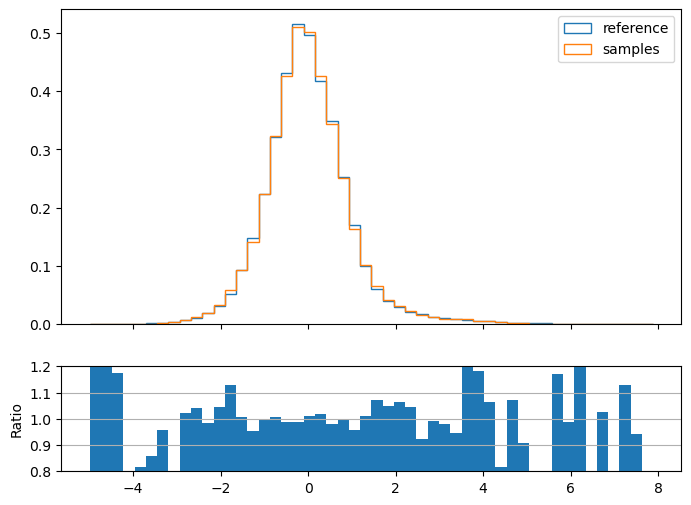

In [10]:
with torch.no_grad():
    samples = flow_herw.sample(100000)[0].detach().cpu().numpy()
qrnn.plotPair(herw_test[:,0],samples[:,0])

In [22]:
torch.save(flow_pyth,"NF_models_QR_general/HerwigToPythia_contrastiveSpace_qcd/flow0_pyth_GIS_embed0.pt")
torch.save(flow_herw,"NF_models_QR_general/HerwigToPythia_contrastiveSpace_qcd/flow0_herw_GIS_embed0.pt")

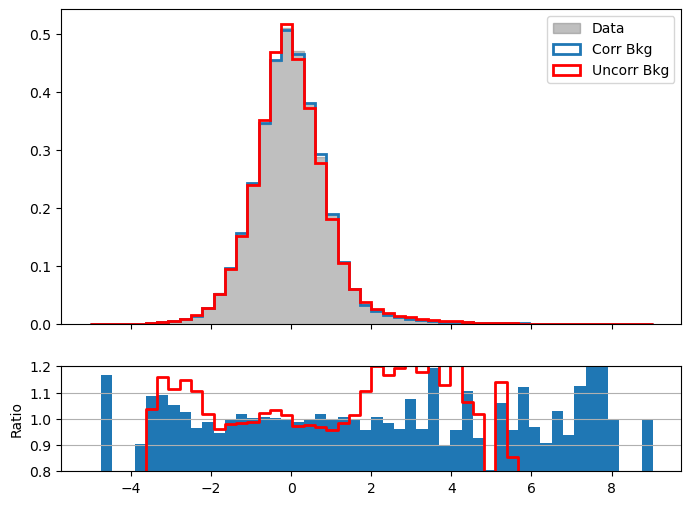

In [8]:
qrnn.plotTriplet(pyth_test[:,0],corr_test[:,0],herw_test[:,0])

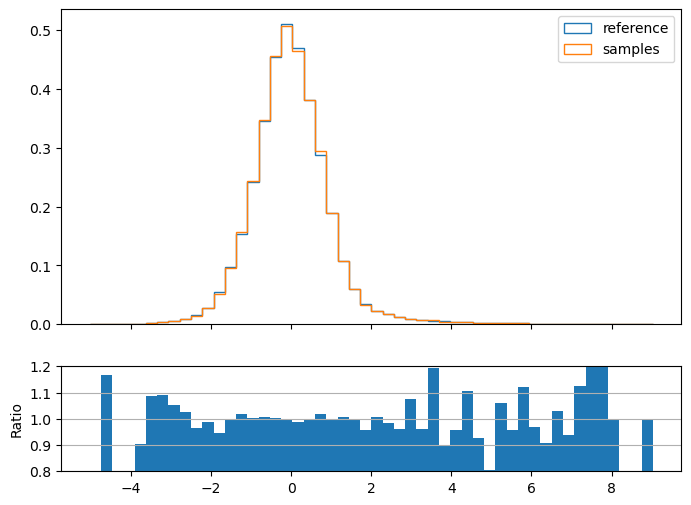

In [9]:
qrnn.plotPair(pyth_test[:,0],corr_test[:,0])

In [8]:
NF_kwargs = {"flow_type":"NSRATQUAD","tail_bound":3.2,"hidden_features":150,
             "num_layers":1,"num_bins":30,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
rangeScale = 3
variables = [f"embed_{k}" for k in range(feat_pyth.shape[1])]
trainer = qrnn.chainedNFTrainer("HerwigToPythia_contrastiveSpace_qcd",herw2_train,herw2_test,pyth_train,pyth_test,variables,control=[0],
                                NF_kwargs=NF_kwargs,rangeScale=rangeScale,separateScale=False)

100%|██████████| 19/19 [00:01<00:00, 14.97it/s]


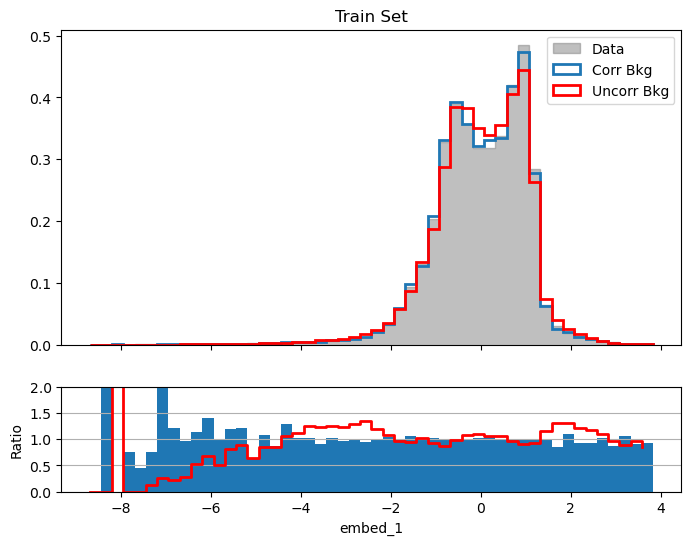

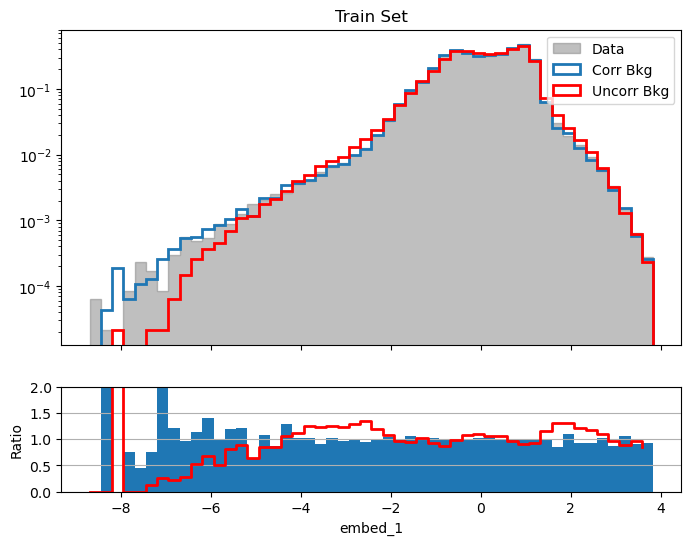

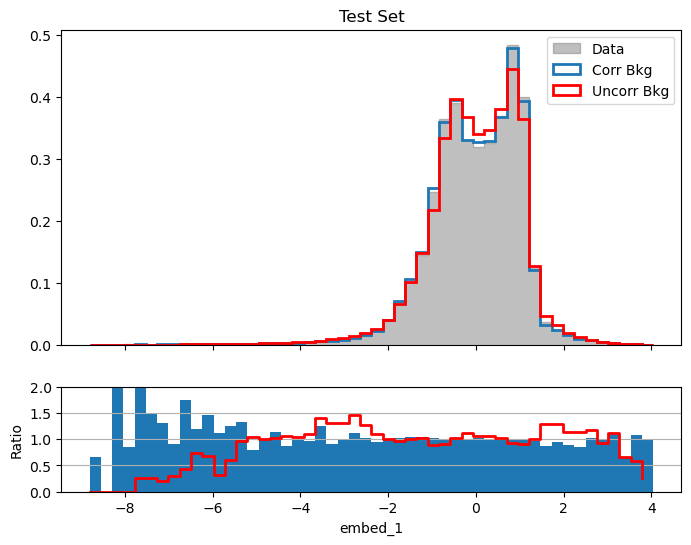

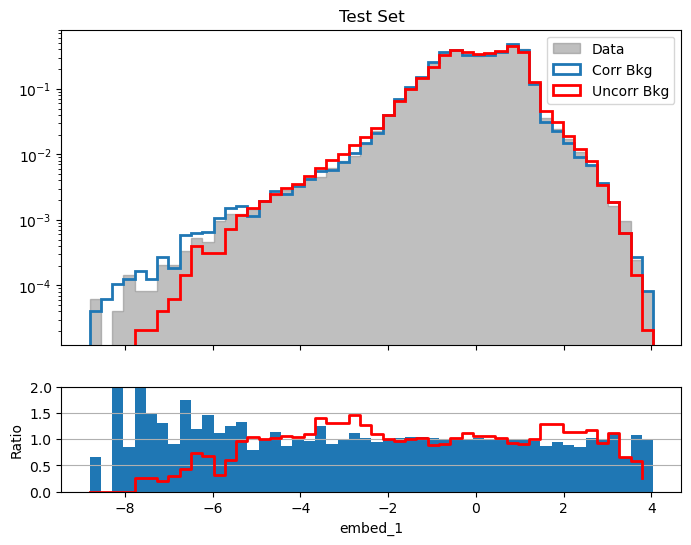

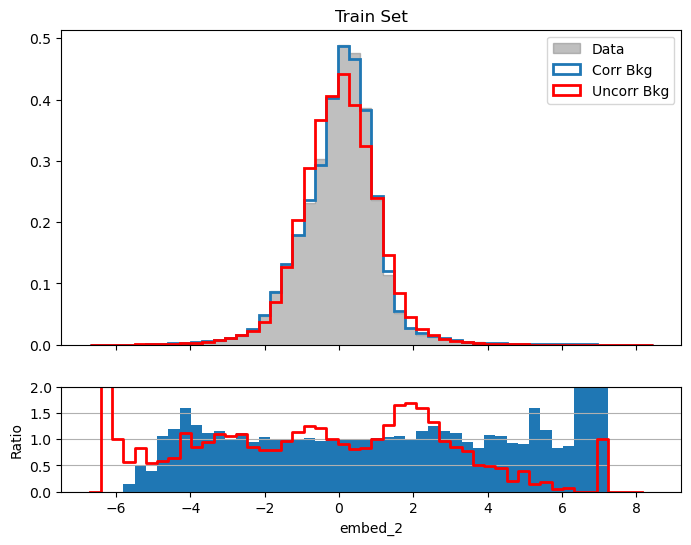

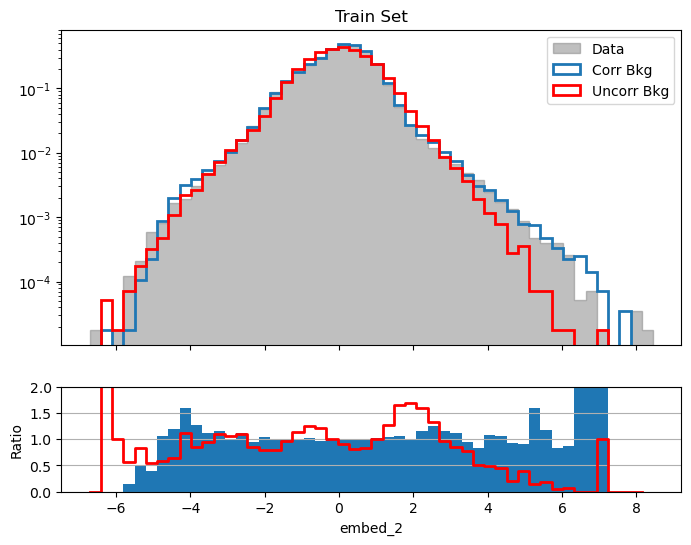

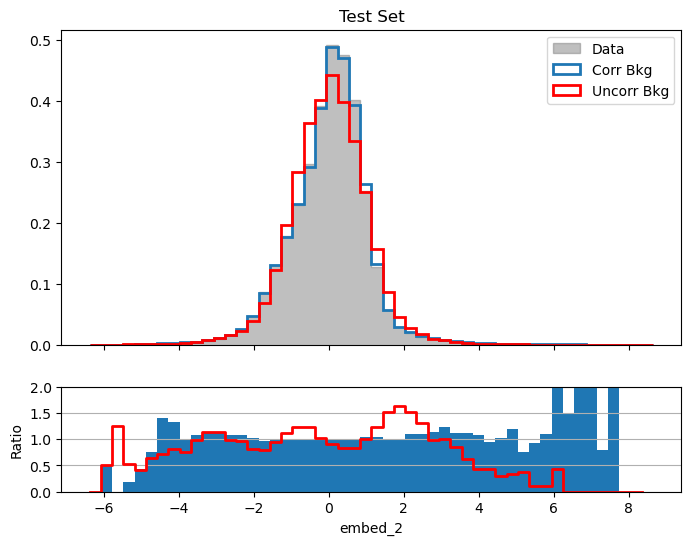

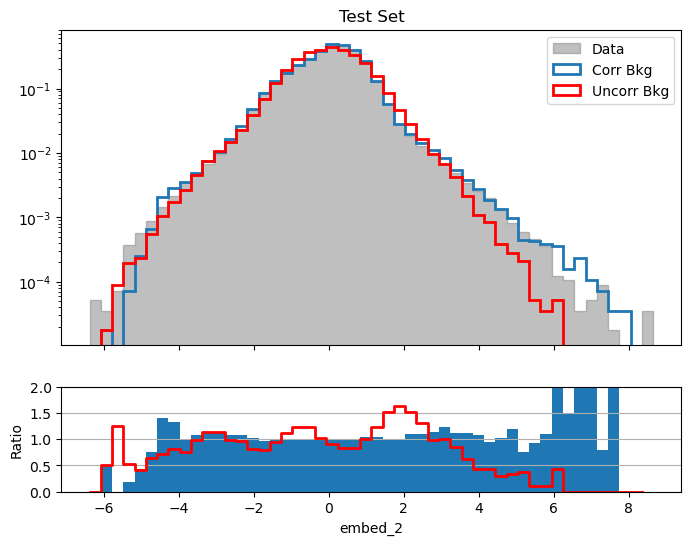

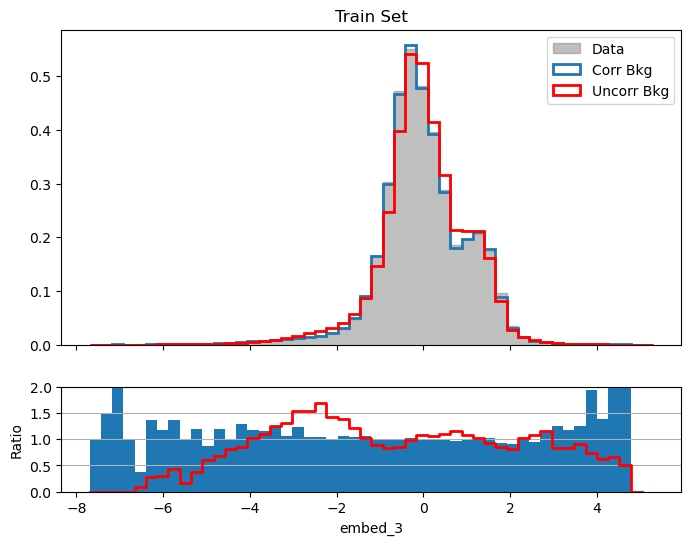

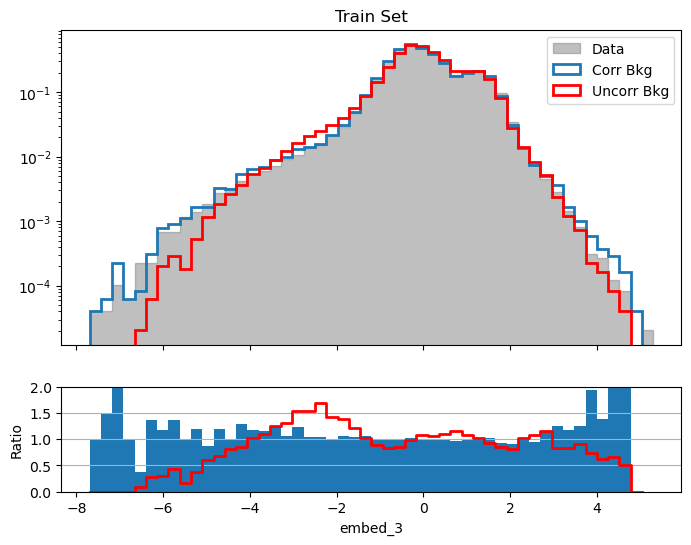

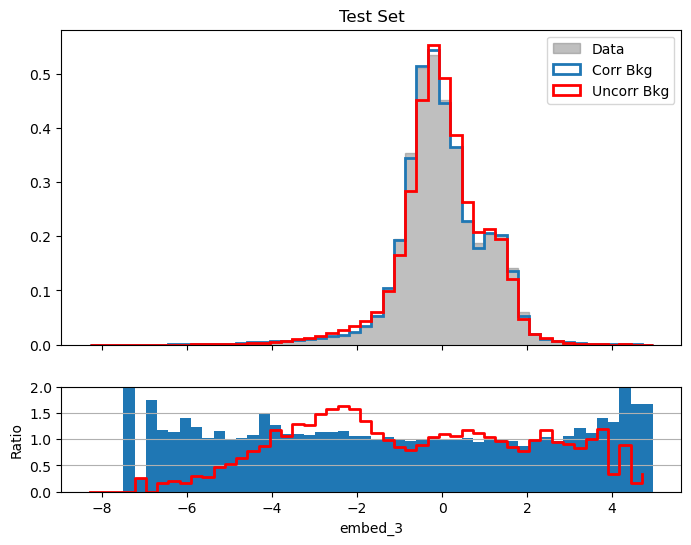

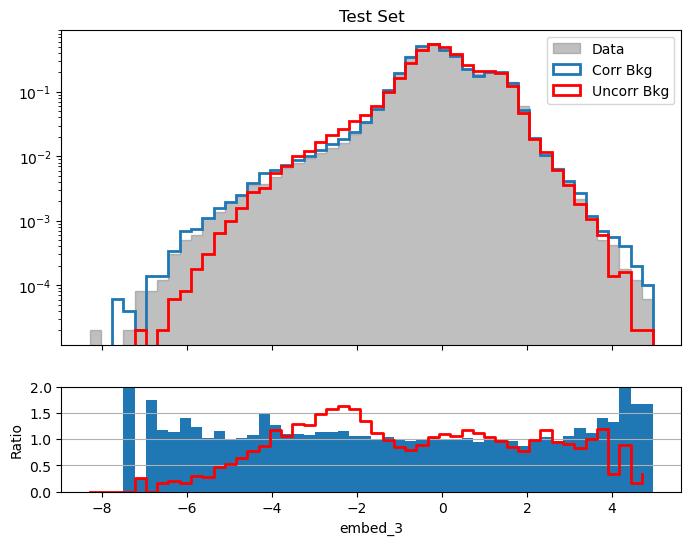

In [11]:
for i in range(3):
    trainer.loadCurrent()
    trainer.correctCurrent()
    trainer.plotCurrent(50,xlim=None,ylim=[0,2])
    trainer.stepForward()

# embed dim 1

Training flow bkgFlow_step0_embed_1


Loss: 0.466777800321579, p = 472: 100%|██████████| 918/918 [01:03<00:00, 14.44it/s]  


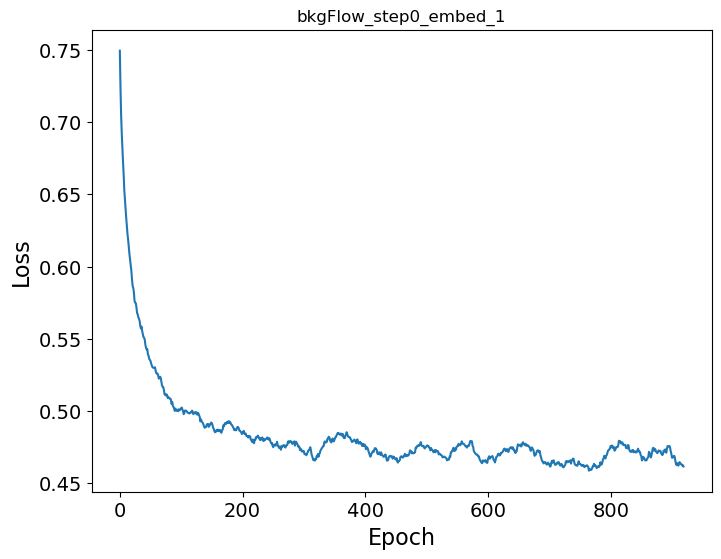

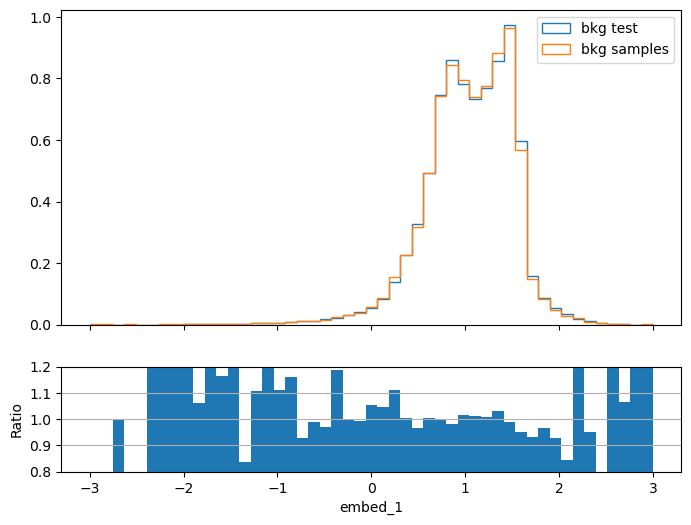

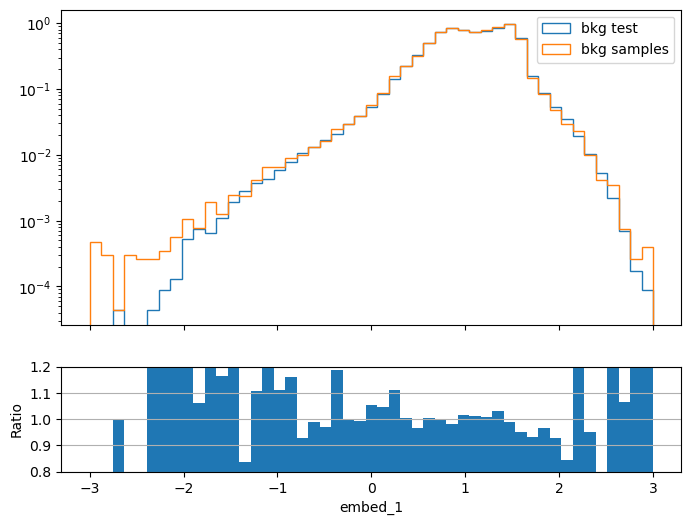

In [9]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":100,
             "num_layers":5,"num_bins":15,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 1024
n_epoch = 5
n_iter = n_epoch*pyth_train.shape[0]//bs
trainer.trainCurrentBkg(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(bkg=True)

Training flow dataFlow_step0_embed_1


Loss: 0.4361792975664139, p = 27: 100%|██████████| 918/918 [01:03<00:00, 14.45it/s]  


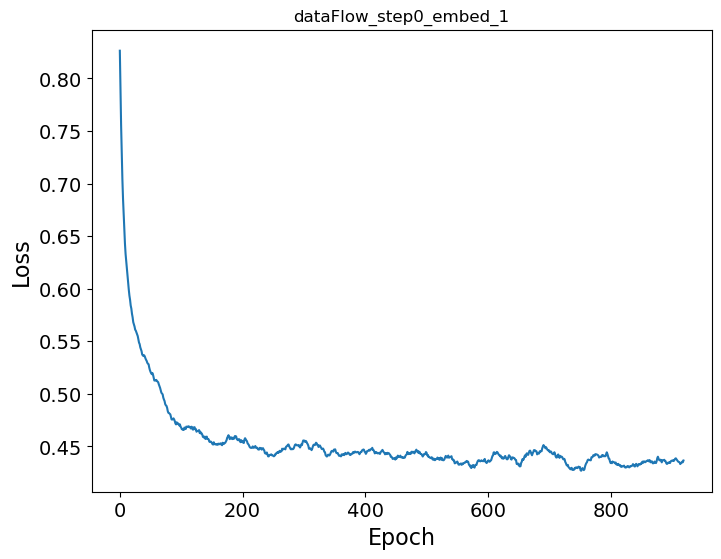

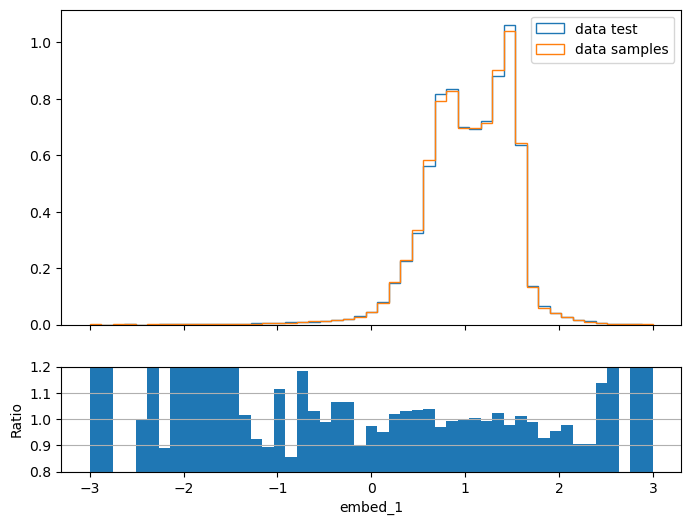

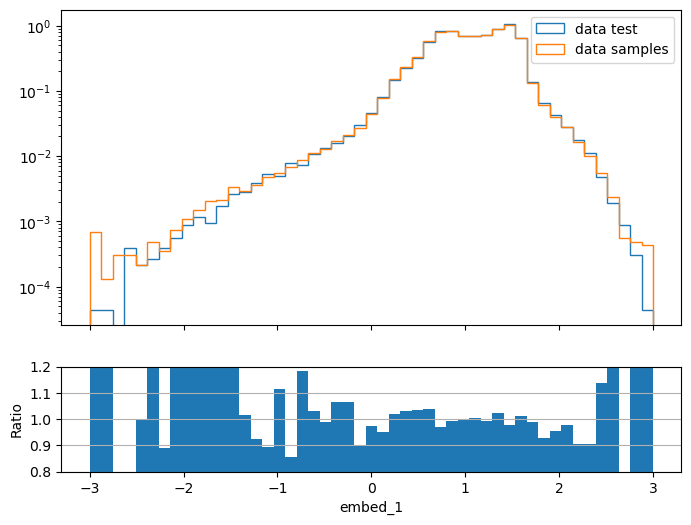

In [45]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":100,
             "num_layers":5,"num_bins":15,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 1024
n_epoch = 5
n_iter = n_epoch*pyth_train.shape[0]//bs
trainer.trainCurrentData(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(data=True)

100%|██████████| 19/19 [00:01<00:00, 13.44it/s]


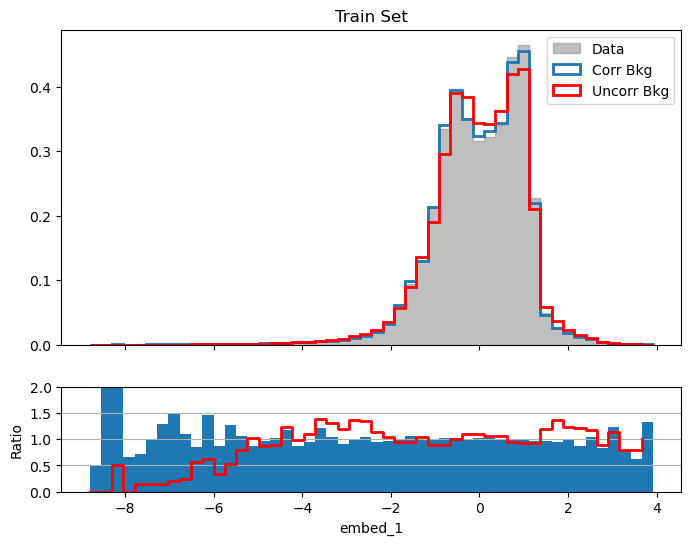

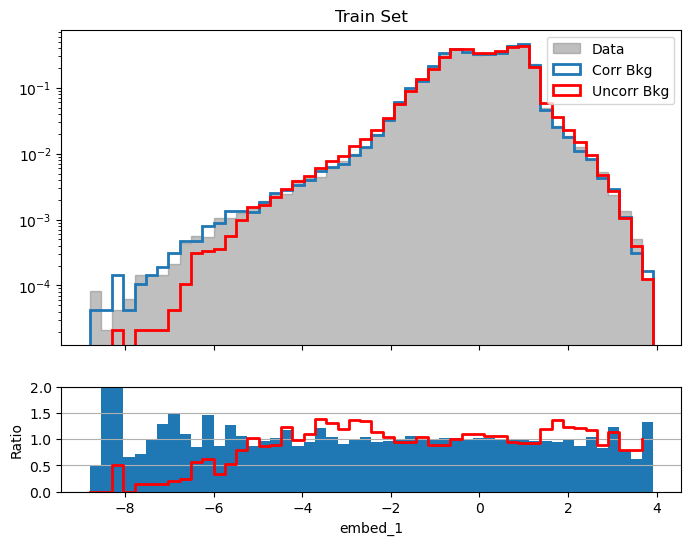

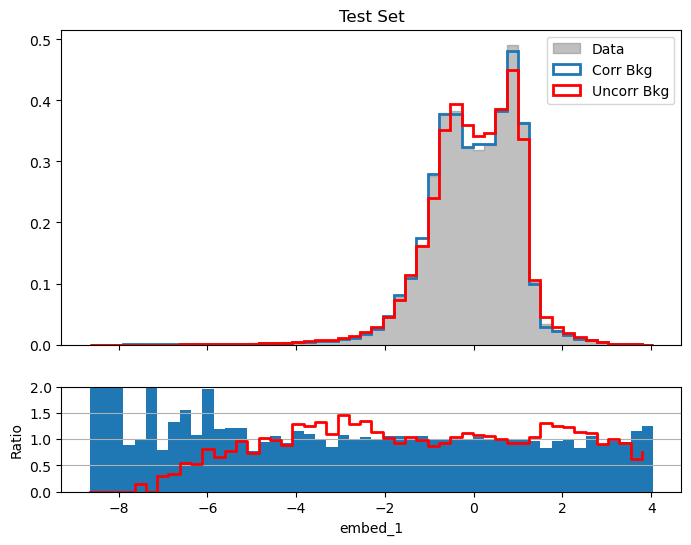

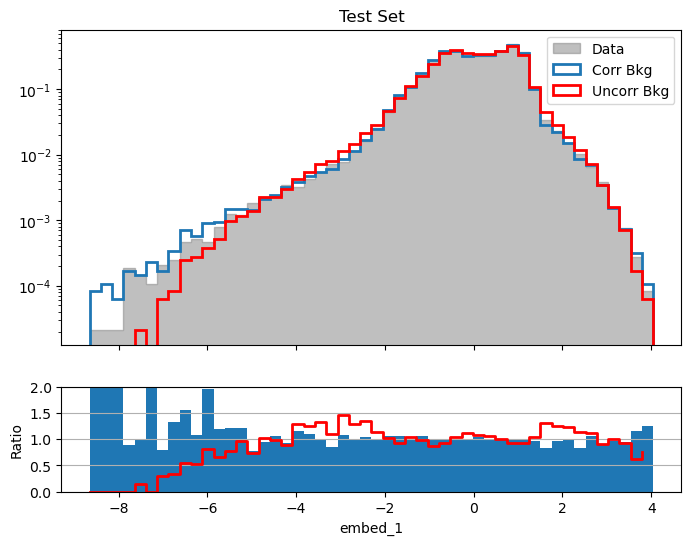

In [47]:
trainer.correctCurrent()
trainer.plotCurrent(50,xlim=None,ylim=[0,2])

In [48]:
trainer.stepForward()

# embed dim 2

Training flow bkgFlow_step1_embed_2


Loss: 0.35265995740890504, p = 186: 100%|██████████| 918/918 [01:05<00:00, 14.10it/s]


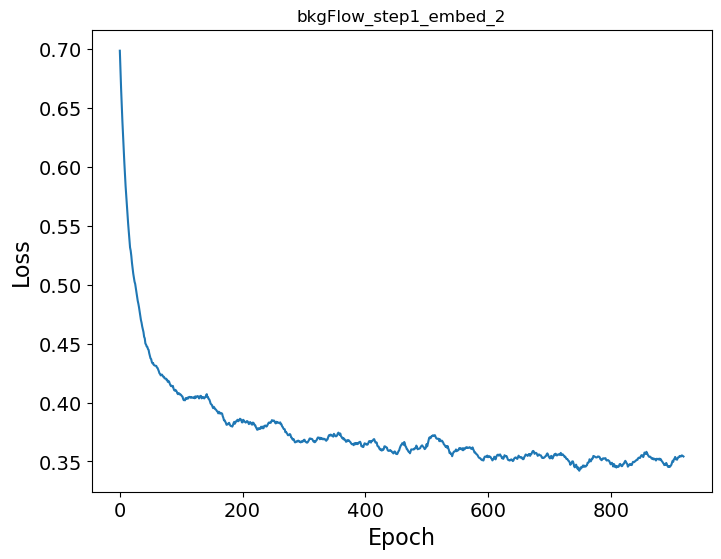

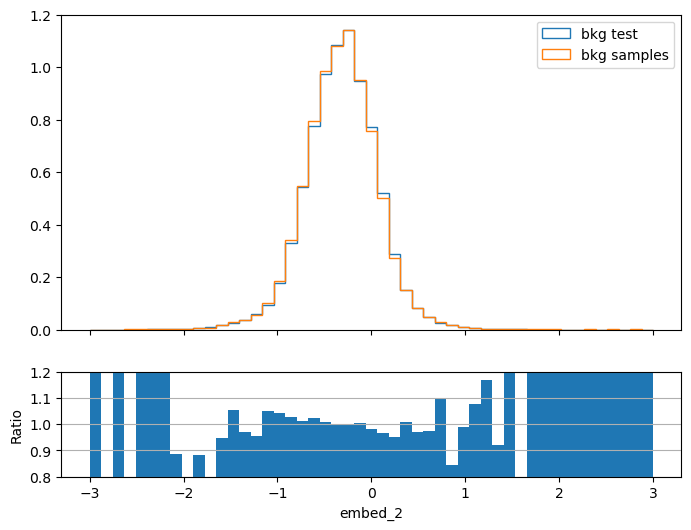

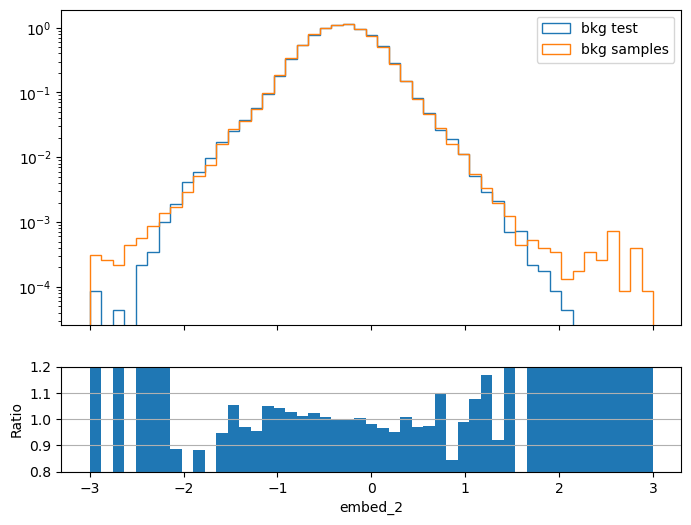

In [51]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":100,
             "num_layers":5,"num_bins":30,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 1024
n_epoch = 5
n_iter = n_epoch*pyth_train.shape[0]//bs
trainer.trainCurrentBkg(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(bkg=True)

Training flow dataFlow_step1_embed_2


Loss: 0.28442337200045587, p = 330: 100%|██████████| 1837/1837 [01:57<00:00, 15.61it/s]


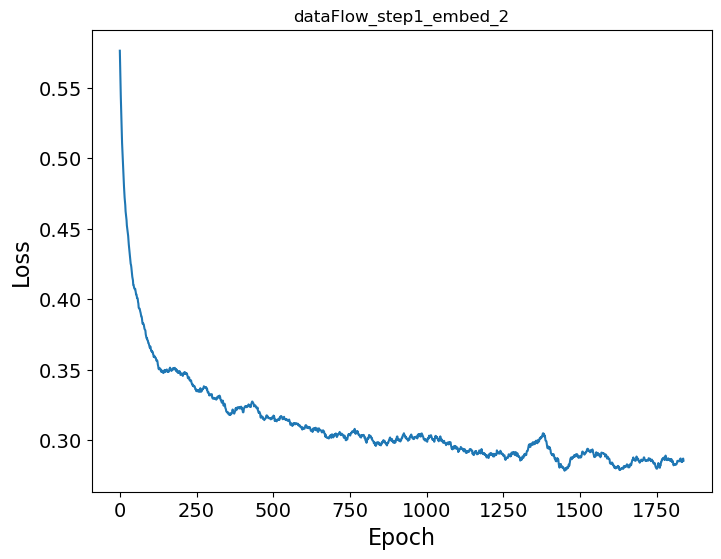

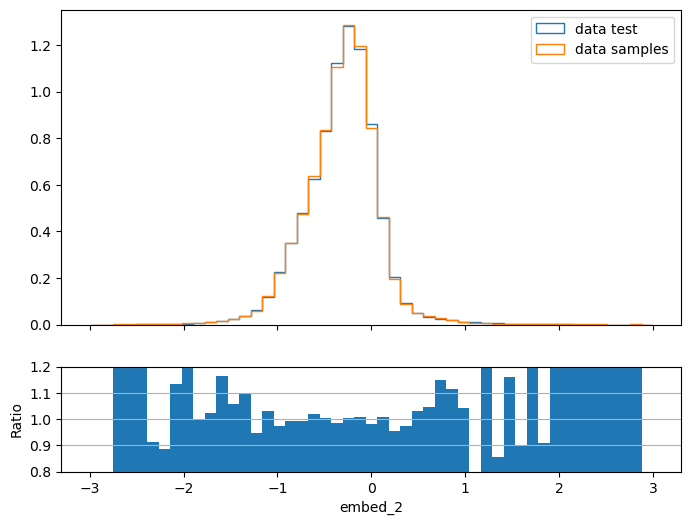

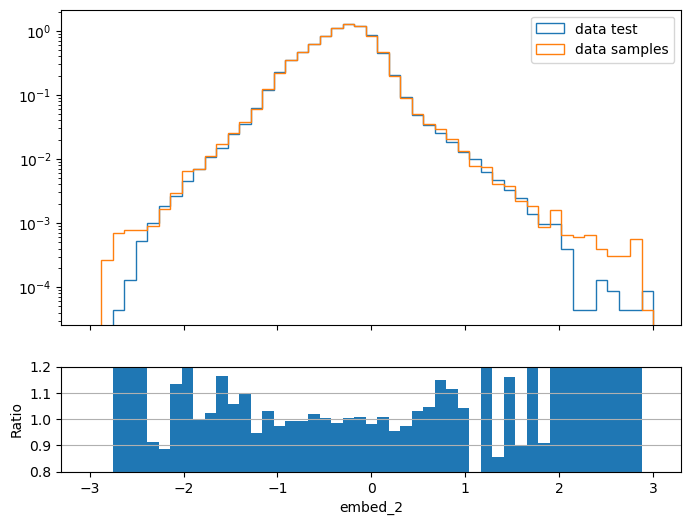

In [52]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":100,
             "num_layers":5,"num_bins":30,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 512
n_epoch = 5
n_iter = n_epoch*pyth_train.shape[0]//bs
trainer.trainCurrentData(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(data=True)

100%|██████████| 19/19 [00:01<00:00, 15.34it/s]


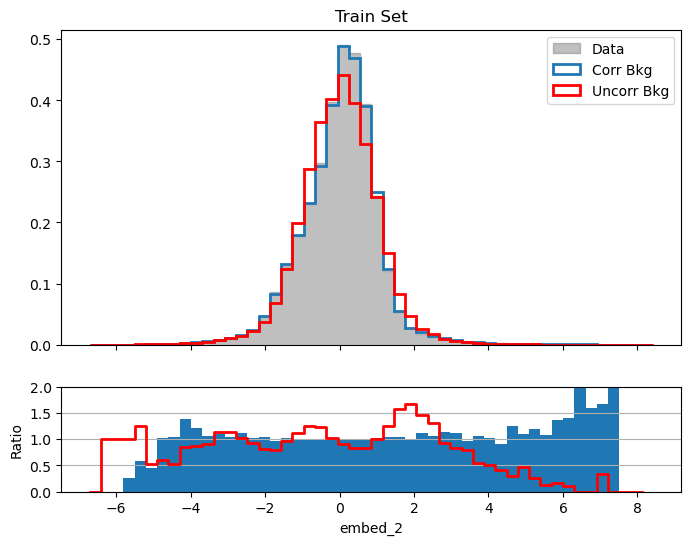

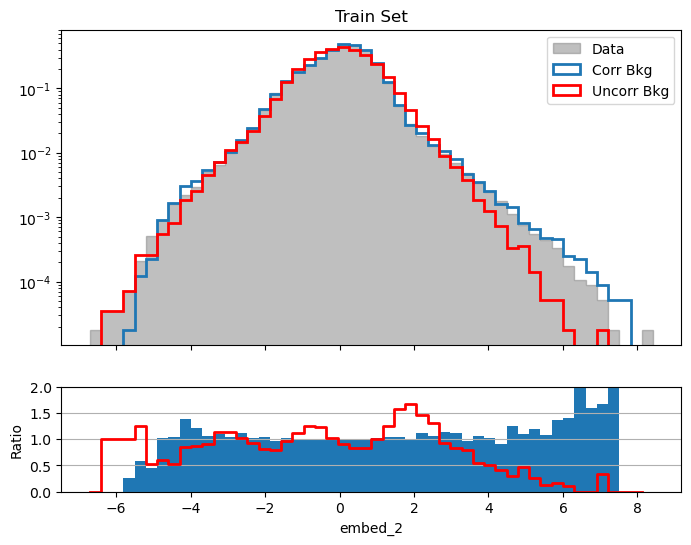

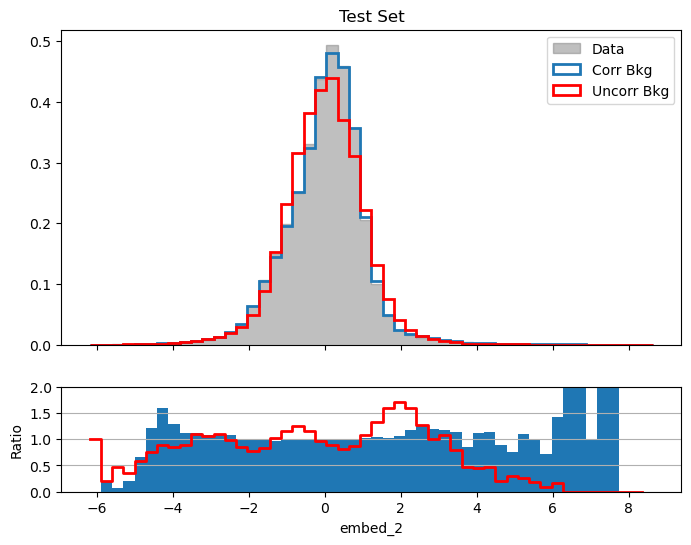

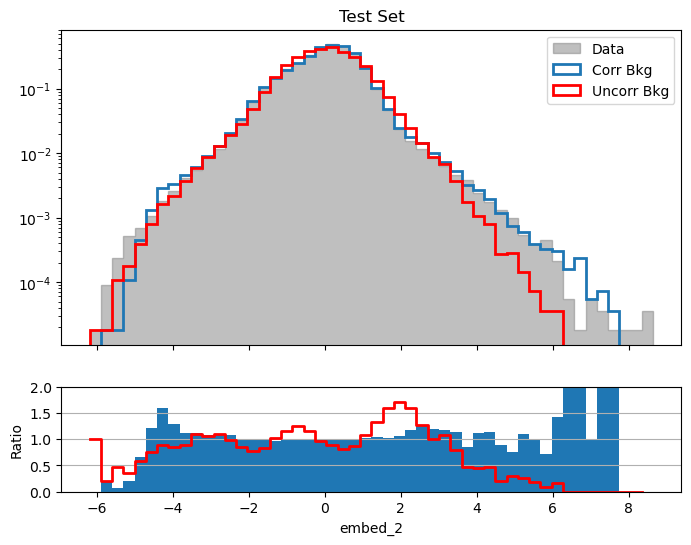

In [54]:
trainer.correctCurrent()
trainer.plotCurrent(50,ylim=[0,2])

In [55]:
trainer.stepForward()

# embed dim 3

Training flow bkgFlow_step2_embed_3


Loss: 0.023226633840240537, p = 105: 100%|██████████| 1837/1837 [02:08<00:00, 14.31it/s]


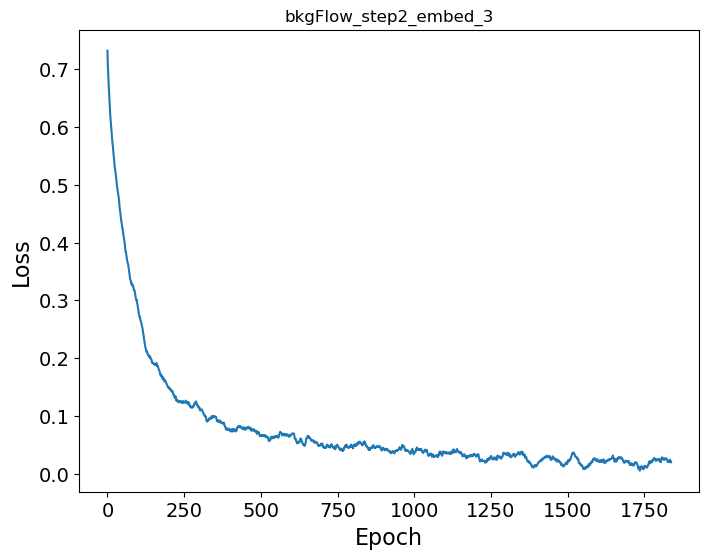

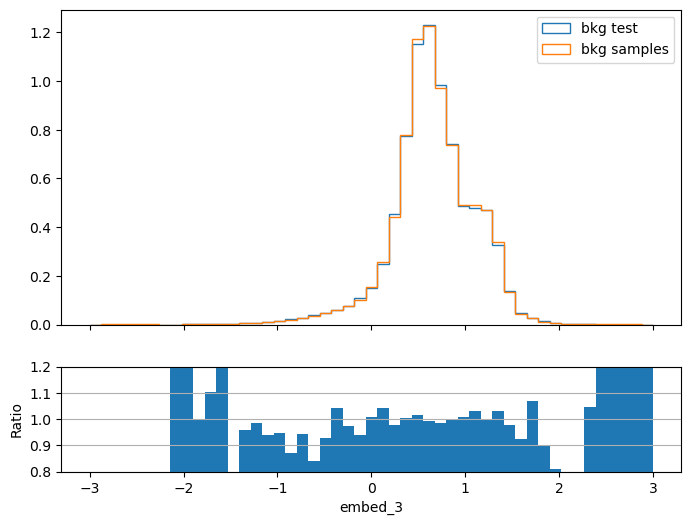

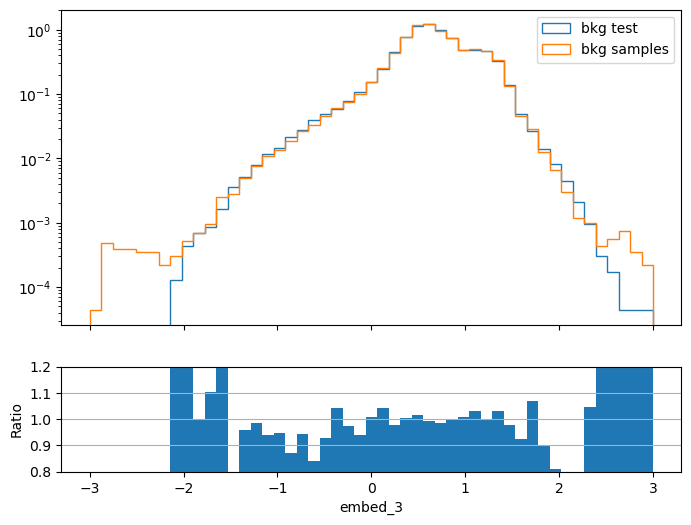

In [57]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":100,
             "num_layers":5,"num_bins":30,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 1024
n_epoch = 10
n_iter = n_epoch*pyth_train.shape[0]//bs
trainer.trainCurrentBkg(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(bkg=True)

Training flow dataFlow_step2_embed_3


Loss: -0.16652528643608094, p = 108: 100%|██████████| 1837/1837 [02:09<00:00, 14.19it/s]


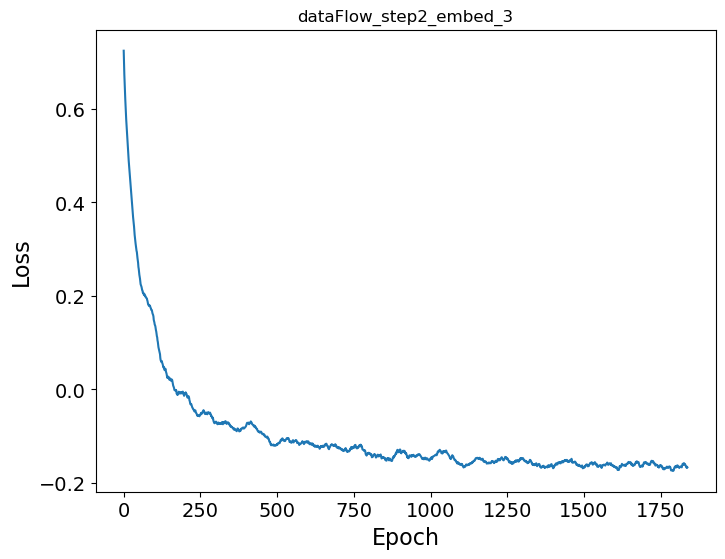

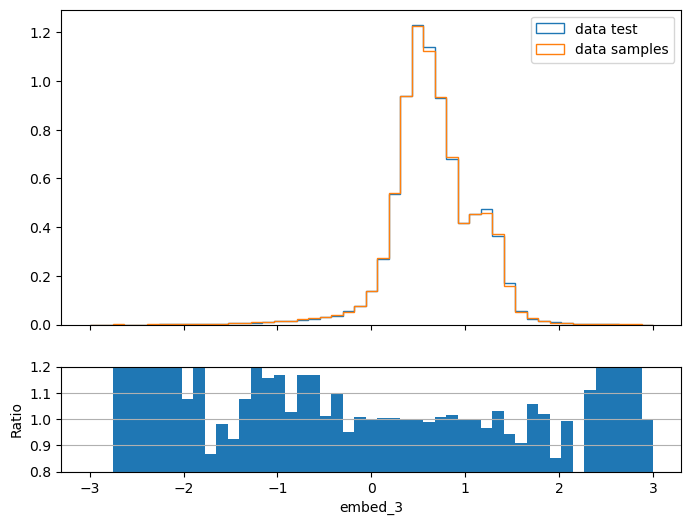

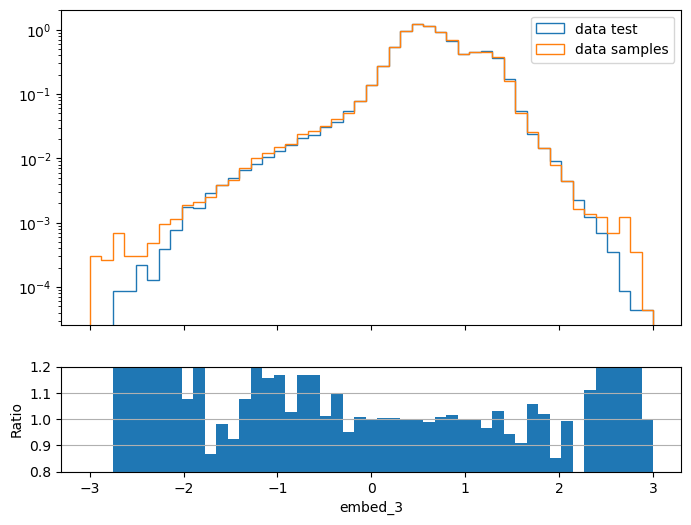

In [58]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":100,
             "num_layers":5,"num_bins":30,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 1024
n_epoch = 10
n_iter = n_epoch*pyth_train.shape[0]//bs
trainer.trainCurrentData(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(data=True)

100%|██████████| 19/19 [00:01<00:00, 15.18it/s]


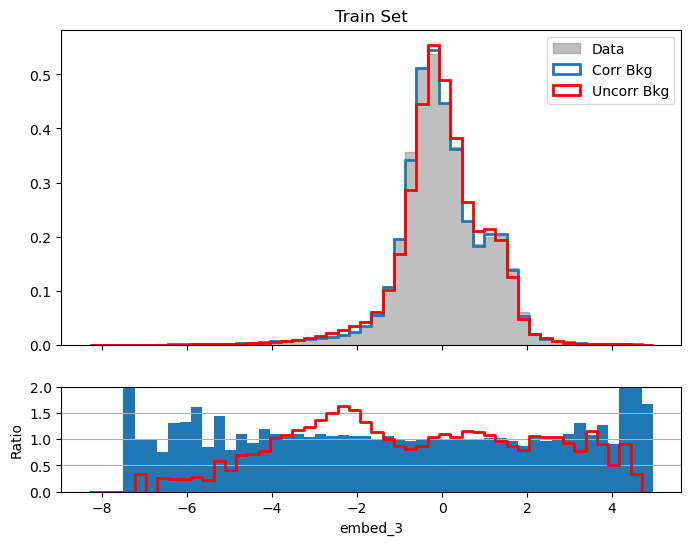

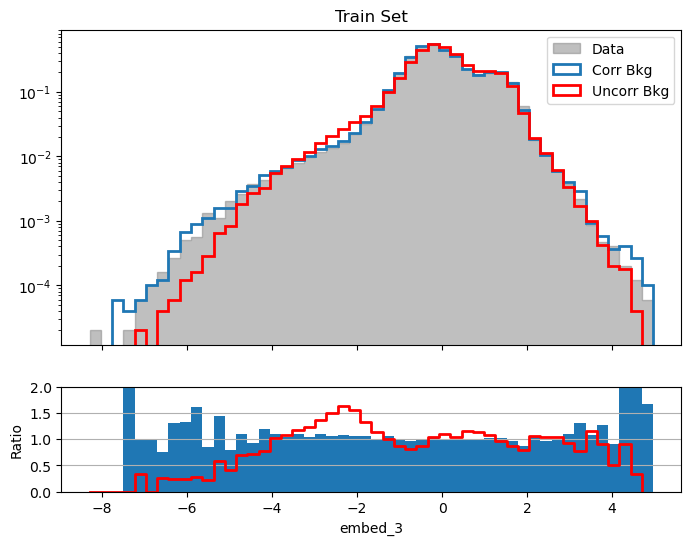

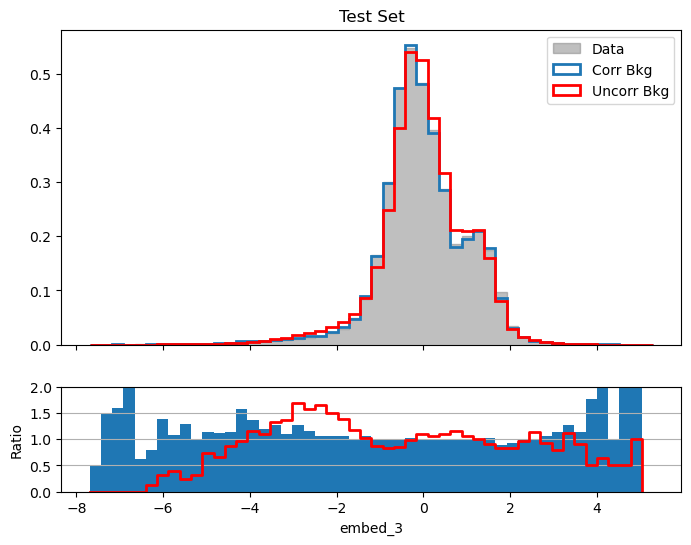

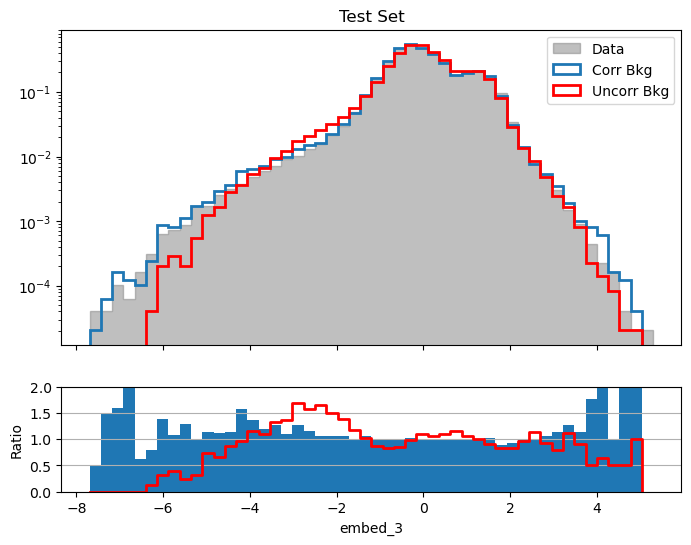

In [60]:
trainer.correctCurrent()
trainer.plotCurrent(50,ylim=[0,2])

# embed dim 4

Training flow bkgFlow_step3_embed_4


Loss: -0.3703261610865593, p = 306: 100%|██████████| 1837/1837 [02:02<00:00, 14.97it/s] 


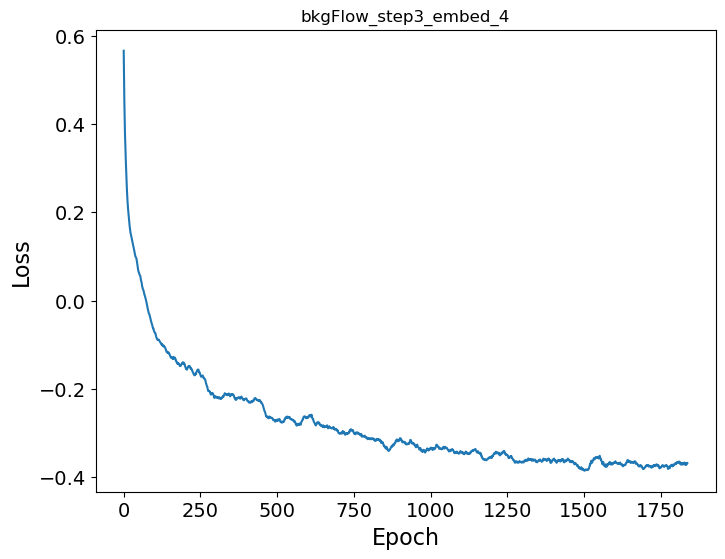

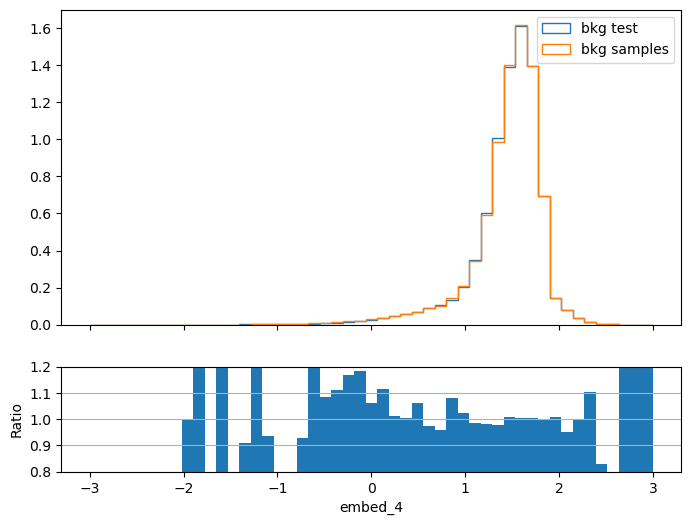

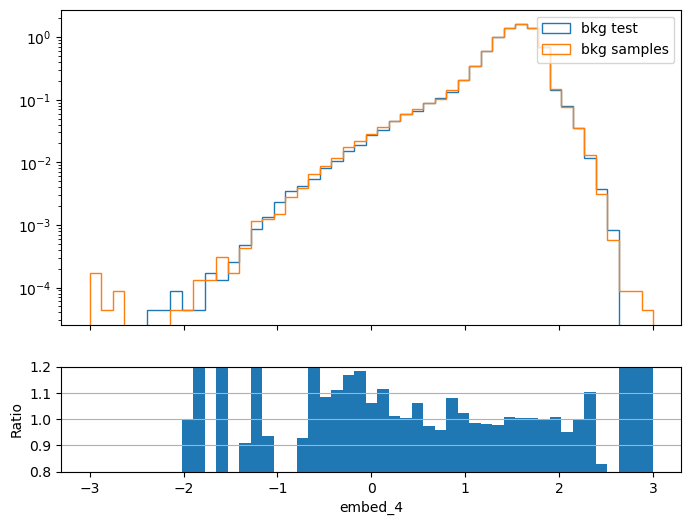

In [16]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":100,
             "num_layers":5,"num_bins":10,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 1024
n_epoch = 10
n_iter = n_epoch*pyth_train.shape[0]//bs
trainer.trainCurrentBkg(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(bkg=True)

Training flow dataFlow_step3_embed_4


Loss: -0.43725083202123644, p = 221: 100%|██████████| 1837/1837 [02:02<00:00, 14.95it/s]


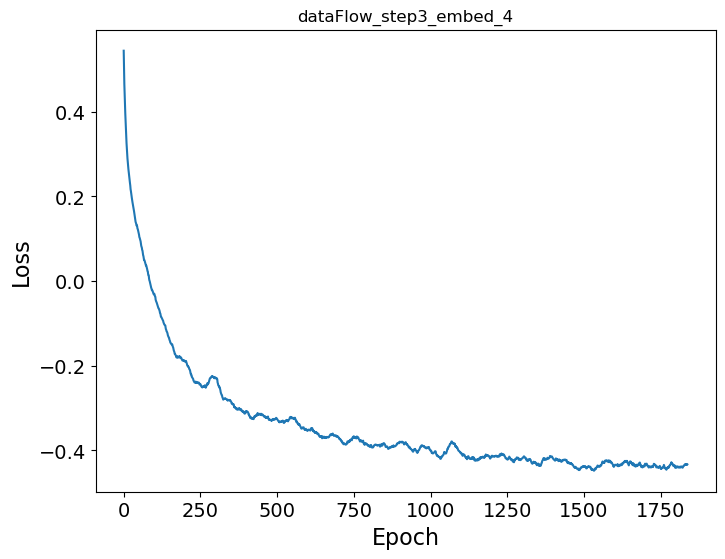

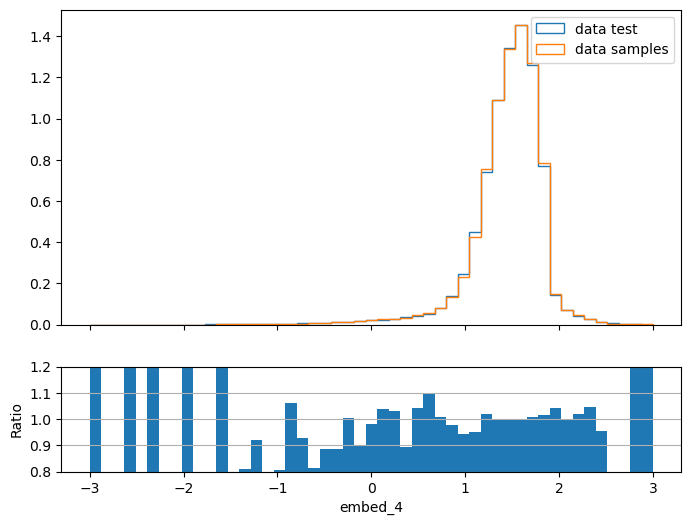

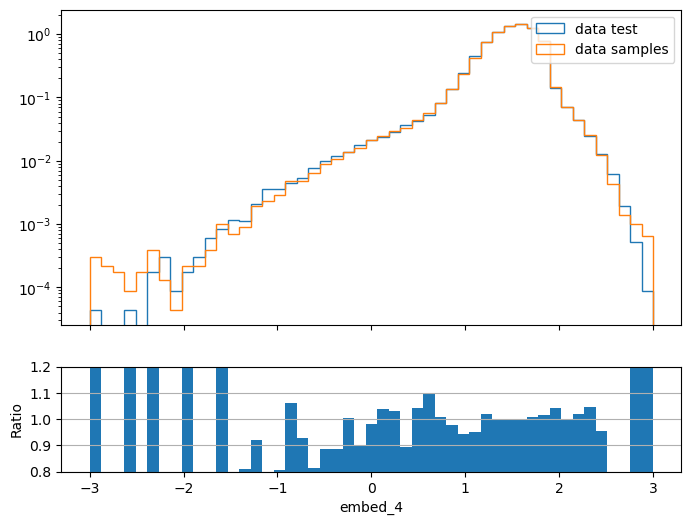

In [17]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":100,
             "num_layers":5,"num_bins":10,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 1024
n_epoch = 10
n_iter = n_epoch*pyth_train.shape[0]//bs
trainer.trainCurrentData(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(data=True)

100%|██████████| 19/19 [00:01<00:00, 13.93it/s]


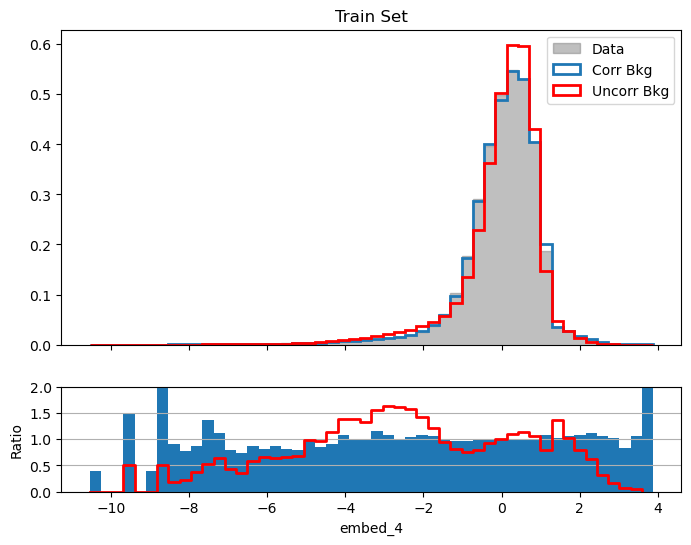

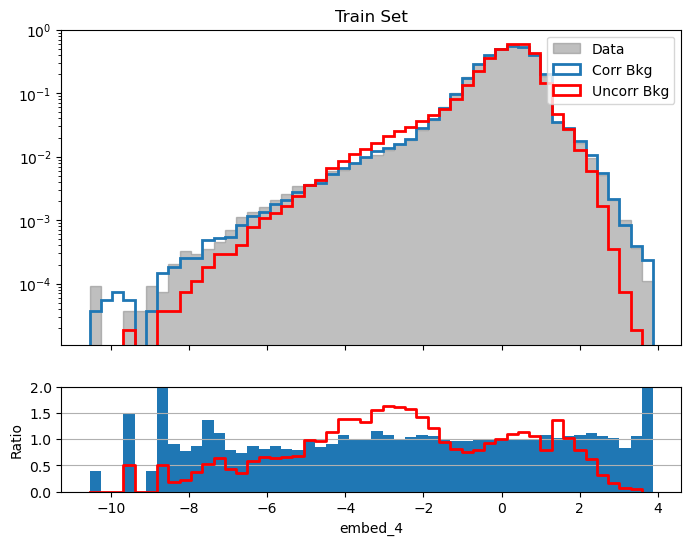

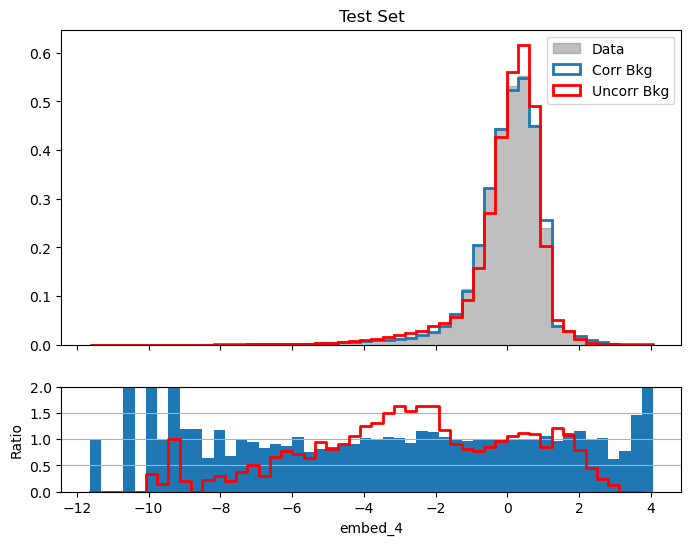

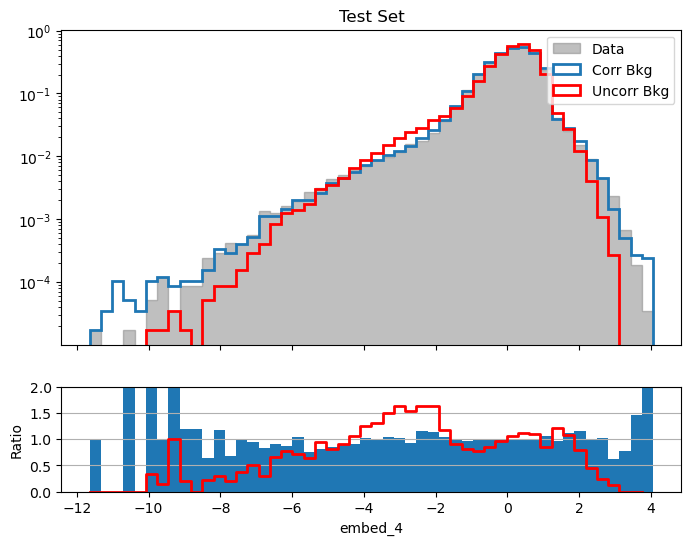

In [18]:
trainer.correctCurrent()
trainer.plotCurrent(50,ylim=[0,2])

In [19]:
trainer.stepForward()

# embed dim 5

Training flow bkgFlow_step4_embed_5


Loss: -0.224267408400774, p = 299: 100%|██████████| 3675/3675 [04:06<00:00, 14.91it/s]   


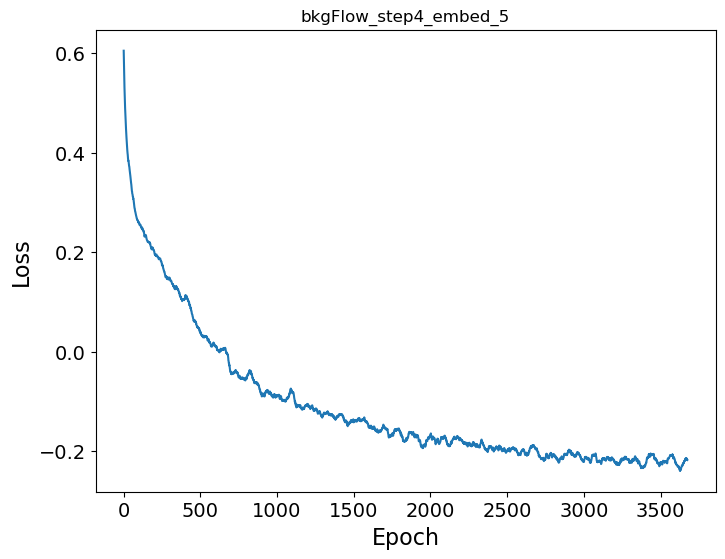

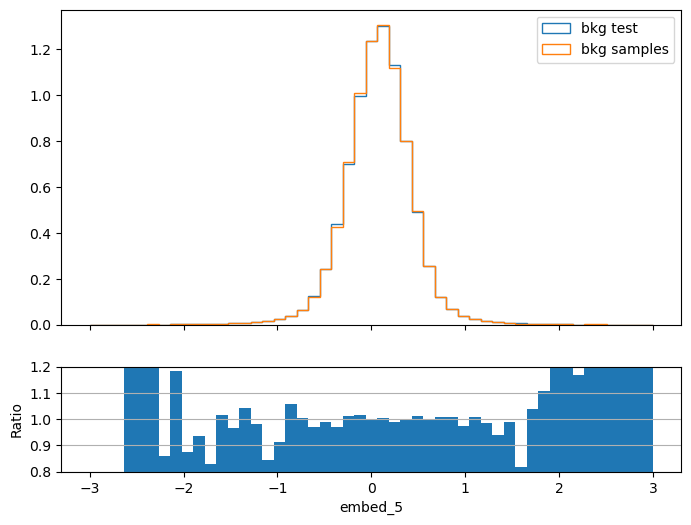

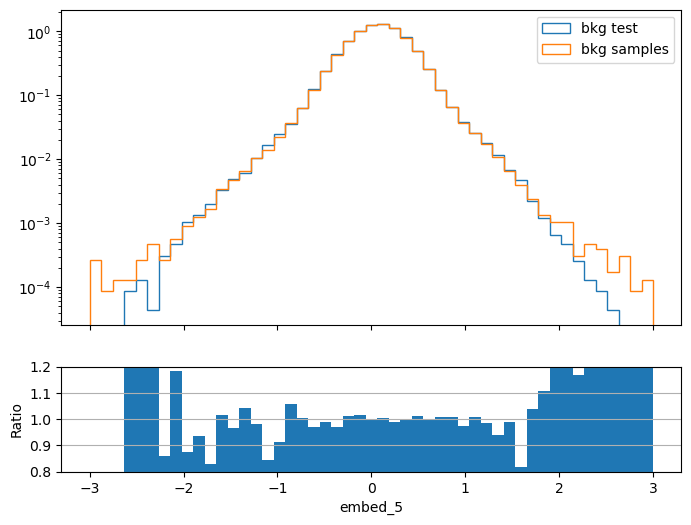

In [25]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":100,
             "num_layers":5,"num_bins":40,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 1024
n_epoch = 20
n_iter = n_epoch*pyth_train.shape[0]//bs
trainer.trainCurrentBkg(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(bkg=True)

Training flow dataFlow_step4_embed_5


Loss: -0.41717384904623034, p = 1177: 100%|██████████| 3675/3675 [04:06<00:00, 14.93it/s]


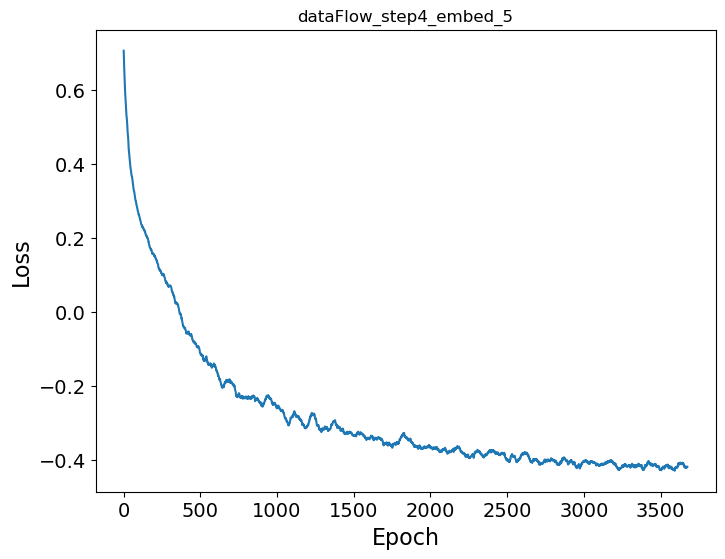

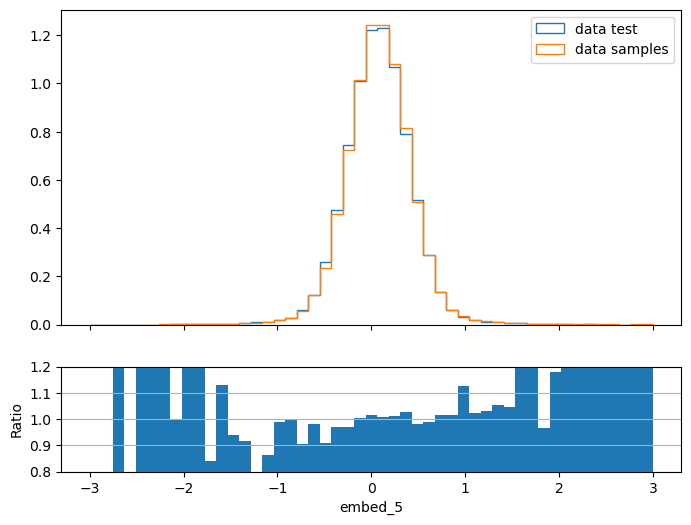

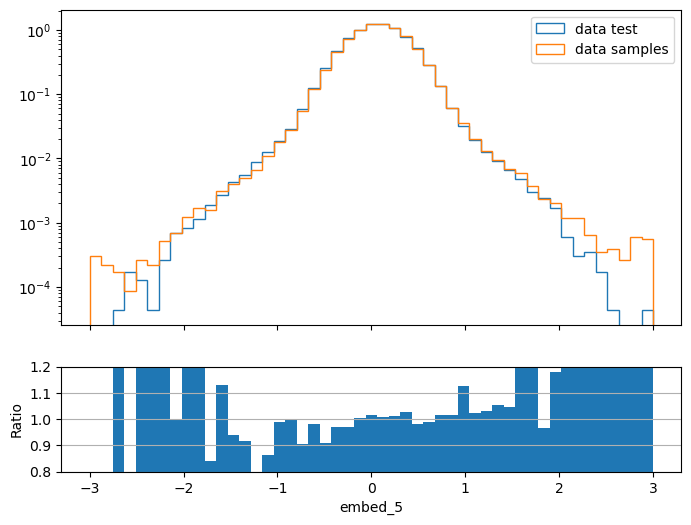

In [32]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":100,
             "num_layers":5,"num_bins":50,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 1024
n_epoch = 20
n_iter = n_epoch*pyth_train.shape[0]//bs
trainer.trainCurrentData(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(data=True)

100%|██████████| 19/19 [00:01<00:00, 14.58it/s]


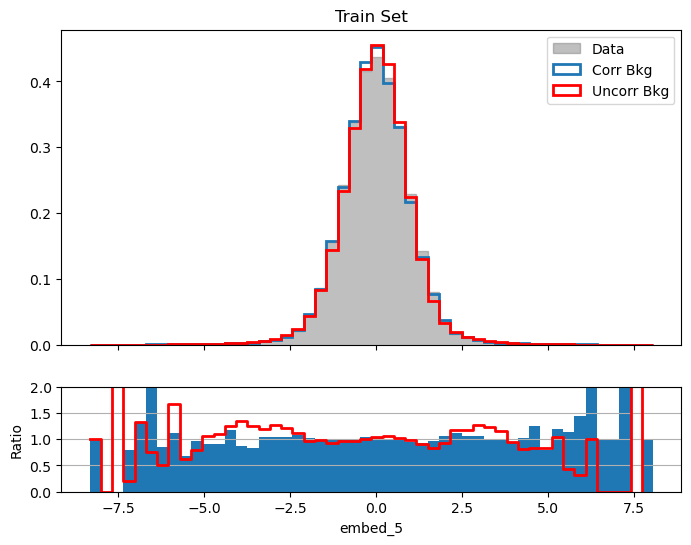

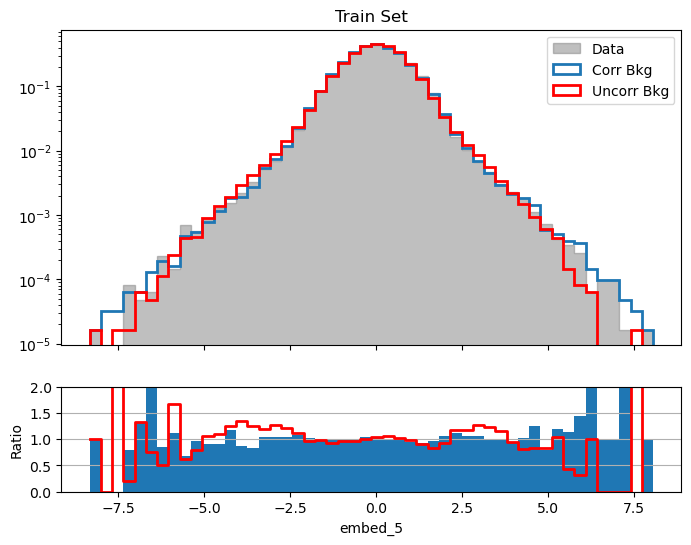

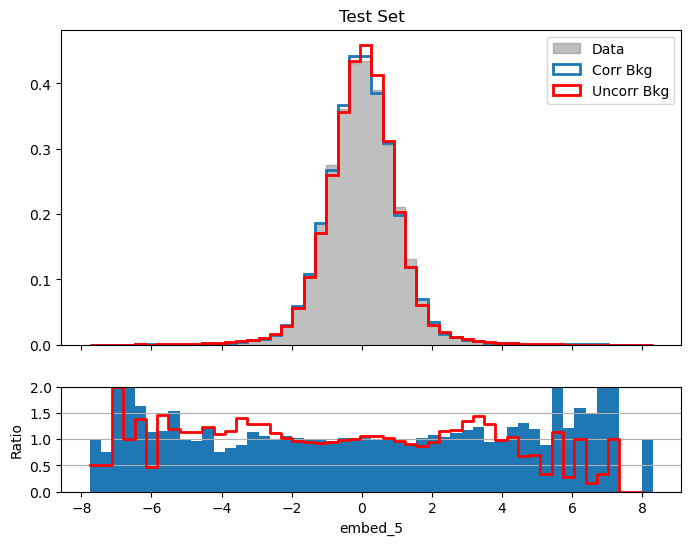

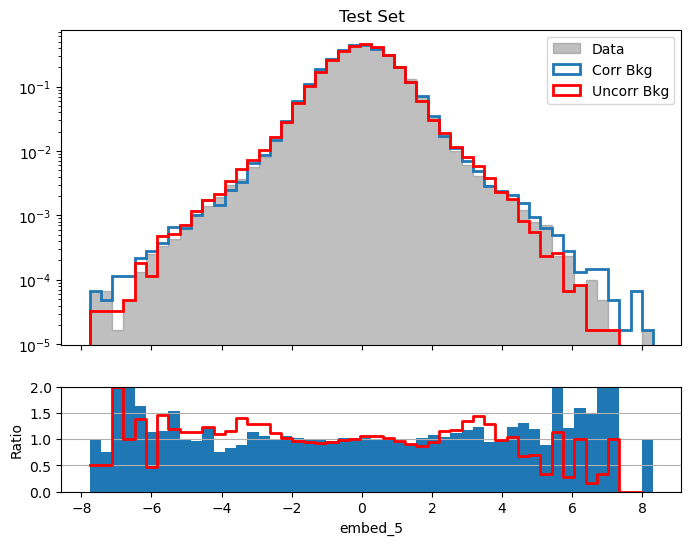

In [33]:
trainer.correctCurrent()
trainer.plotCurrent(50,ylim=[0,2])

In [34]:
trainer.stepForward()

# embed dim 6

Training flow bkgFlow_step5_embed_6


Loss: -0.5003366112709046, p = 211: 100%|██████████| 3675/3675 [04:08<00:00, 14.82it/s] 


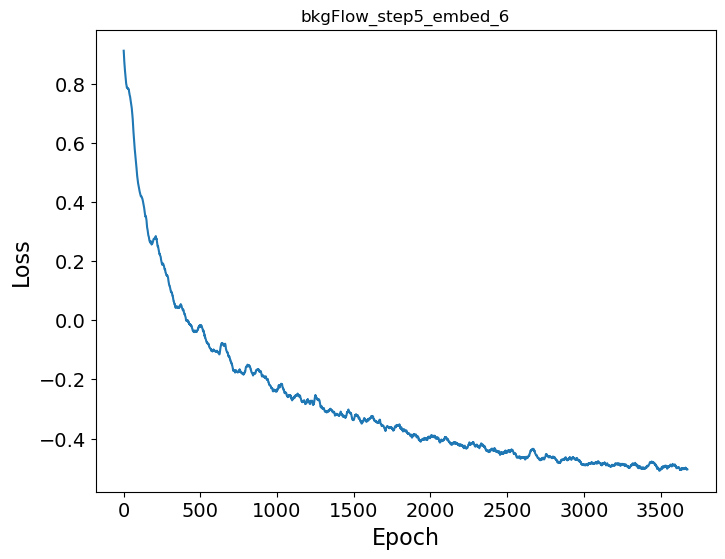

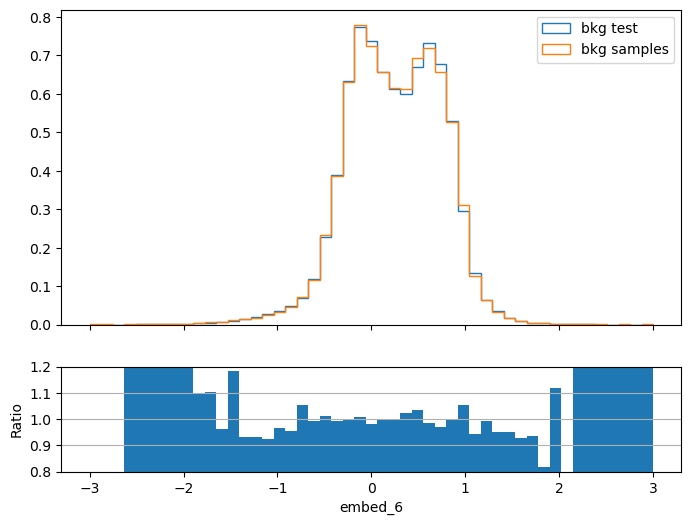

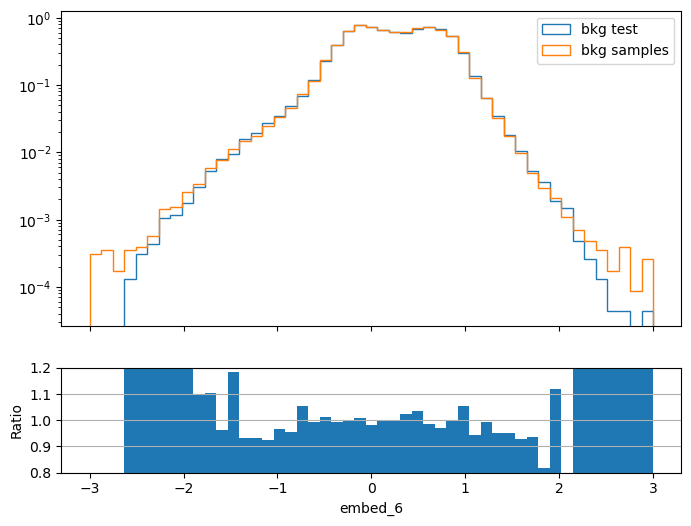

In [44]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":160,
             "num_layers":5,"num_bins":80,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 1024
n_epoch = 20
n_iter = n_epoch*pyth_train.shape[0]//bs
trainer.trainCurrentBkg(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(bkg=True)

Training flow dataFlow_step5_embed_6


Loss: -0.9695057052373887, p = 11: 100%|██████████| 3675/3675 [04:08<00:00, 14.80it/s] 


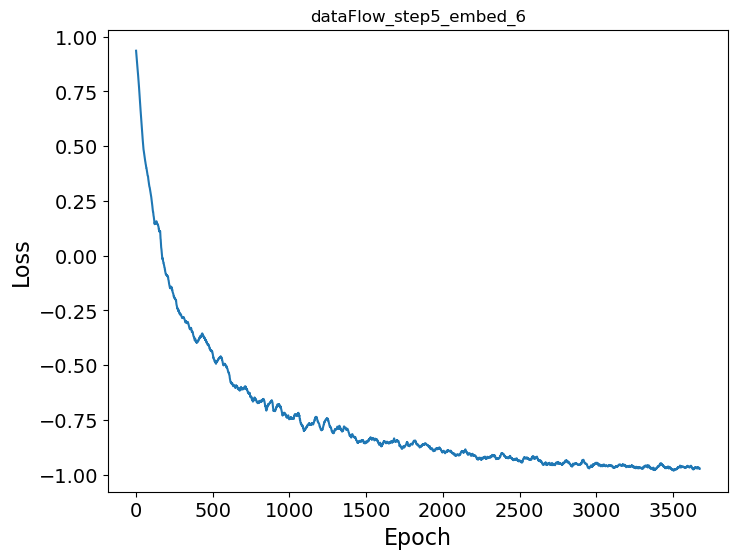

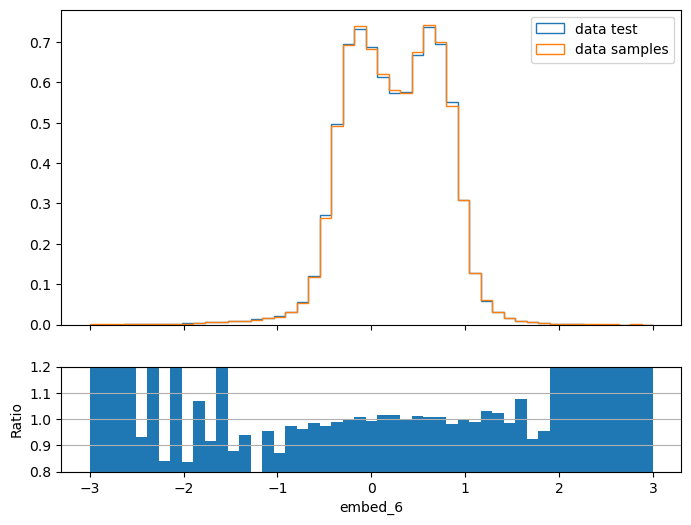

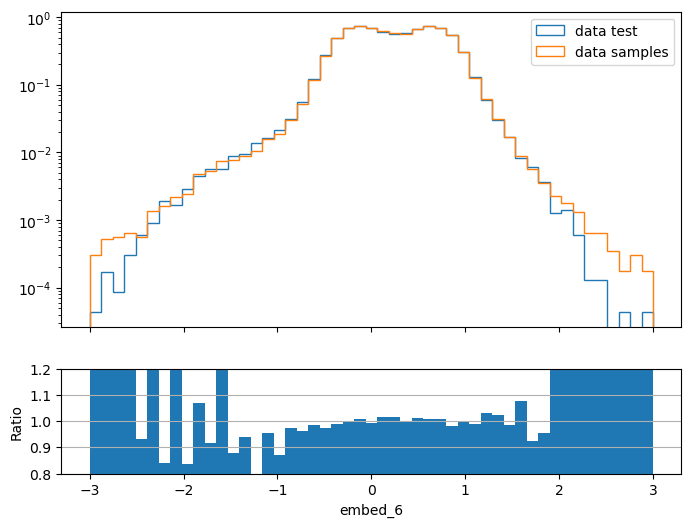

In [46]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":160,
             "num_layers":5,"num_bins":80,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 1024
n_epoch = 20
n_iter = n_epoch*pyth_train.shape[0]//bs
trainer.trainCurrentData(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(data=True)

100%|██████████| 19/19 [00:01<00:00, 11.24it/s]


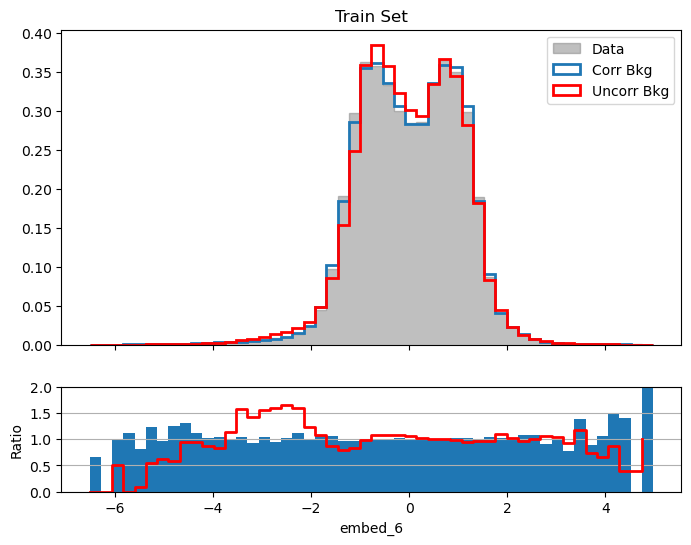

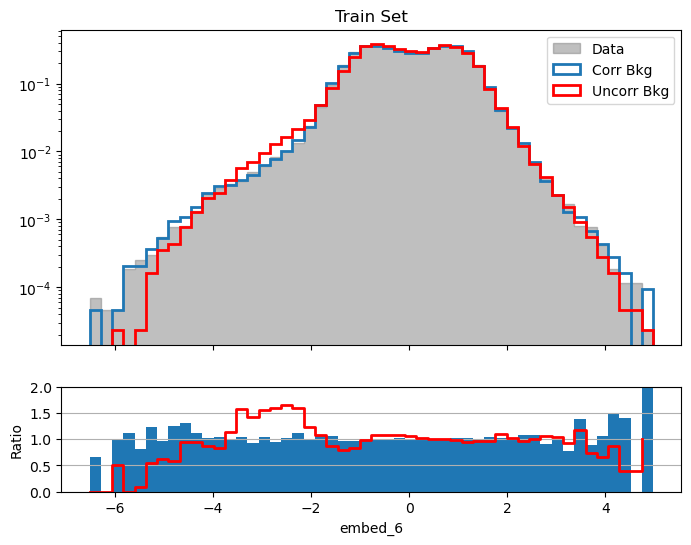

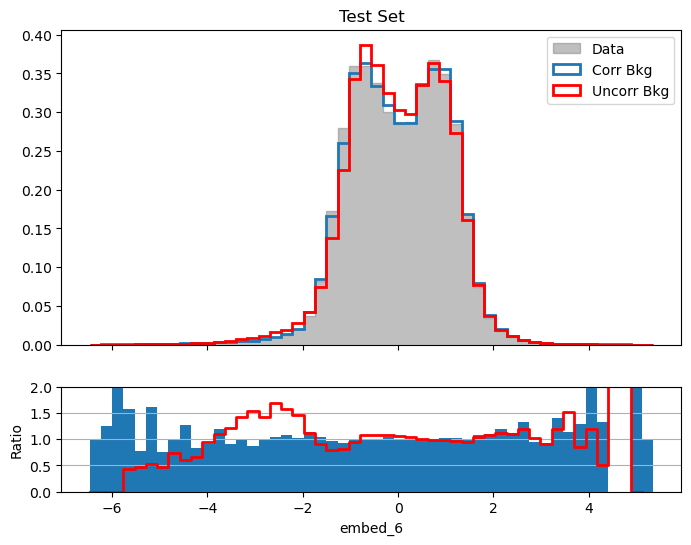

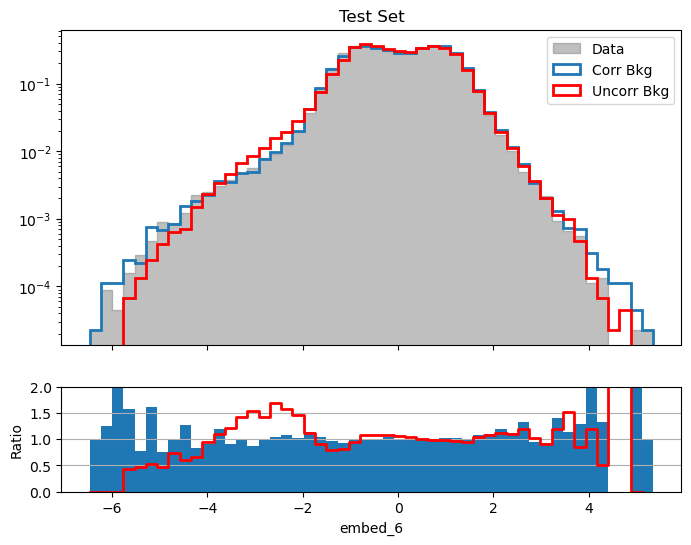

In [47]:
trainer.correctCurrent()
trainer.plotCurrent(50,ylim=[0,2])

In [48]:
trainer.stepForward()

# embed dim 7

Training flow bkgFlow_step6_embed_7


Loss: -0.7831840950250626, p = 501: 100%|██████████| 3675/3675 [04:12<00:00, 14.54it/s]


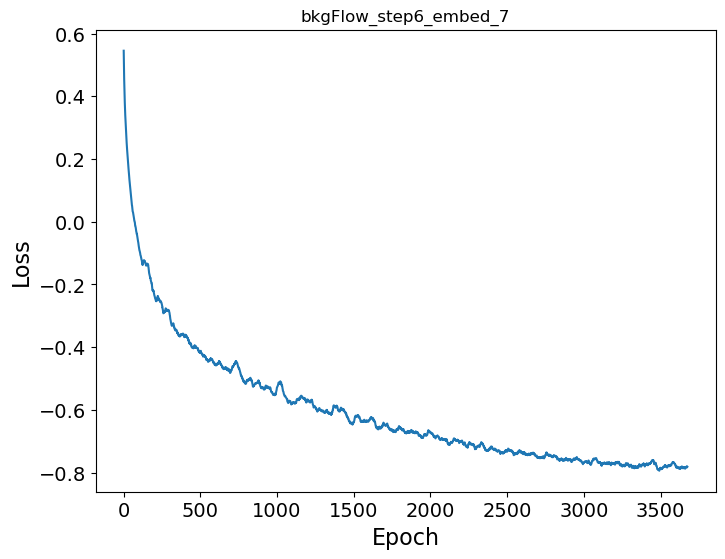

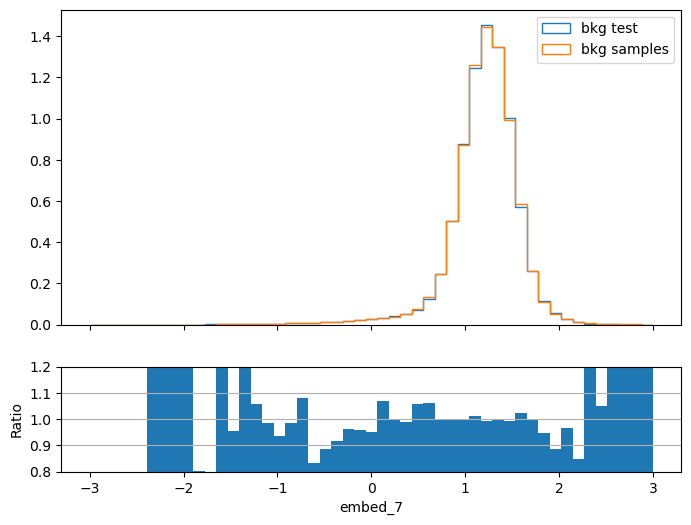

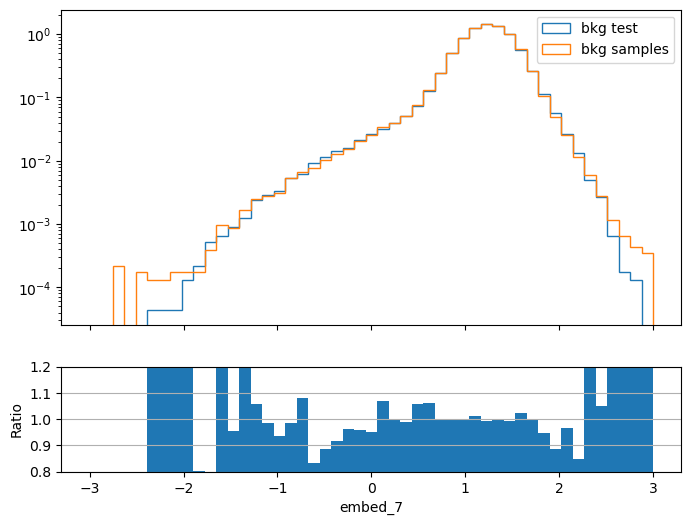

In [50]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":160,
             "num_layers":5,"num_bins":40,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 1024
n_epoch = 20
n_iter = n_epoch*pyth_train.shape[0]//bs
trainer.trainCurrentBkg(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(bkg=True)

Training flow dataFlow_step6_embed_7


Loss: -1.2373125922679902, p = 179: 100%|██████████| 3675/3675 [04:13<00:00, 14.53it/s] 


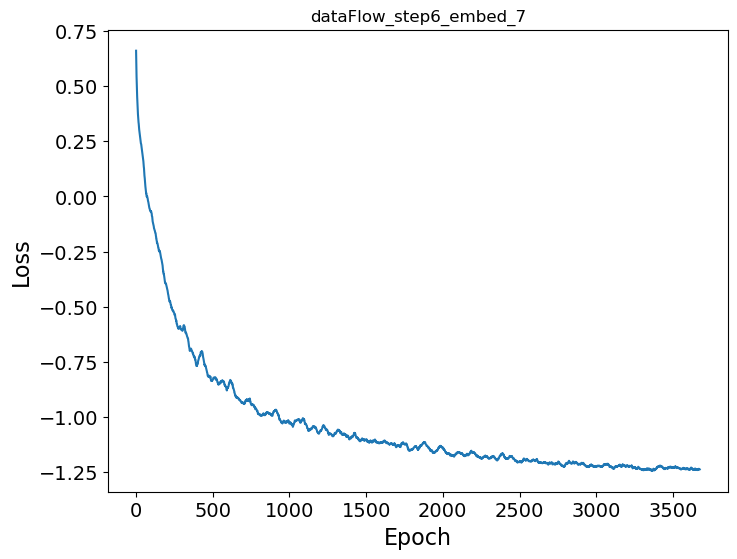

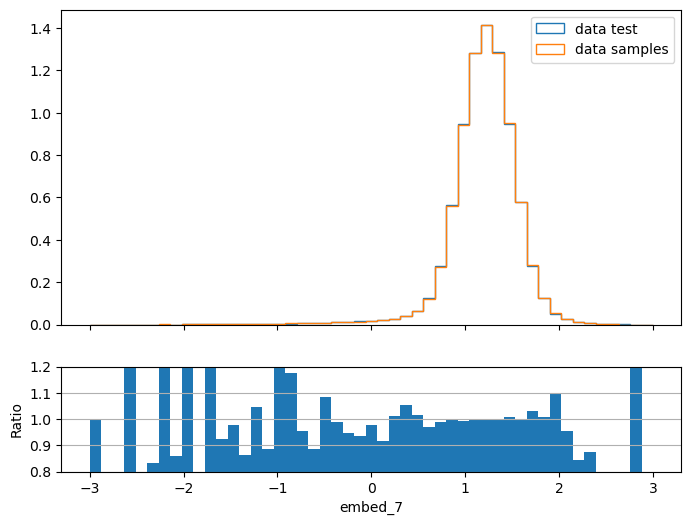

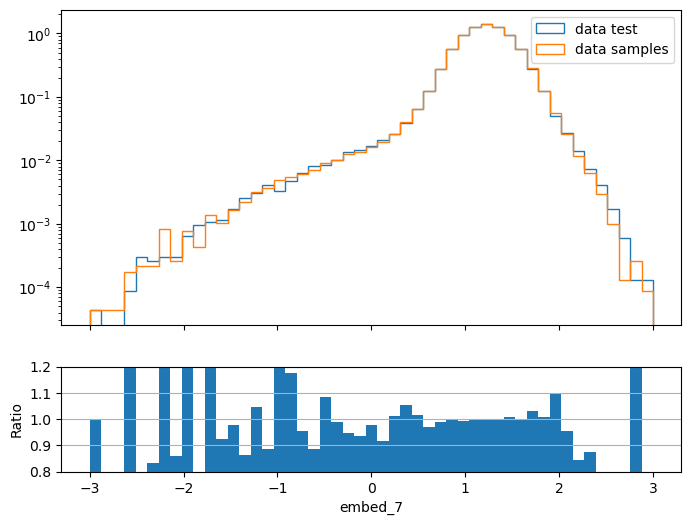

In [51]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":160,
             "num_layers":5,"num_bins":40,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 1024
n_epoch = 20
n_iter = n_epoch*pyth_train.shape[0]//bs
trainer.trainCurrentData(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(data=True)

100%|██████████| 19/19 [00:01<00:00, 13.14it/s]


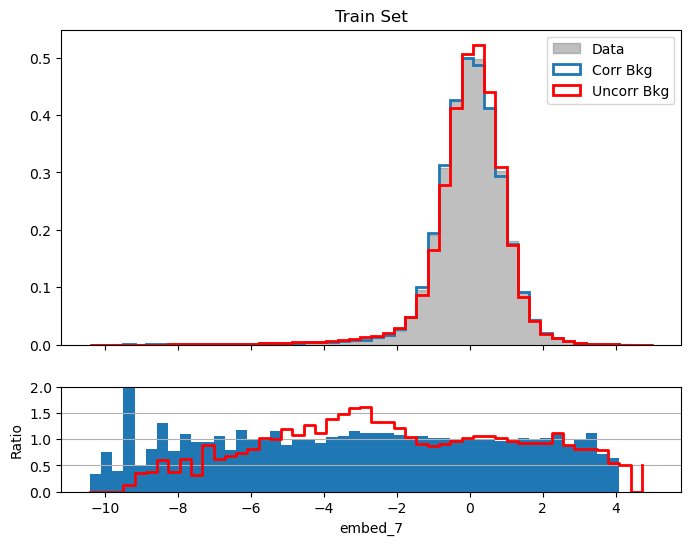

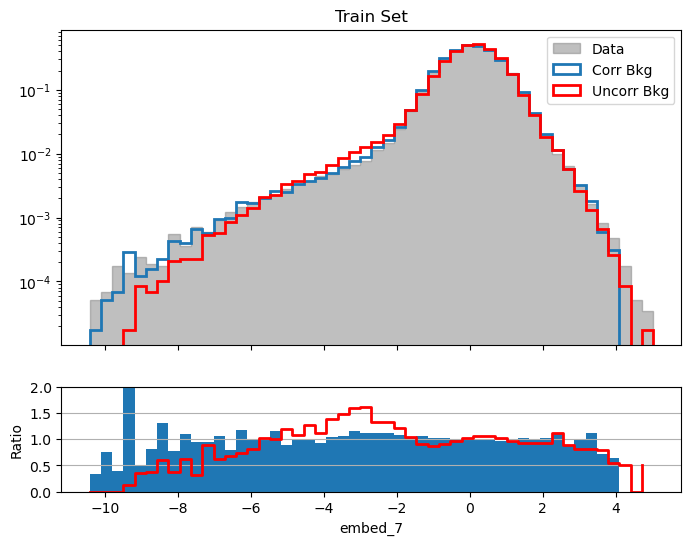

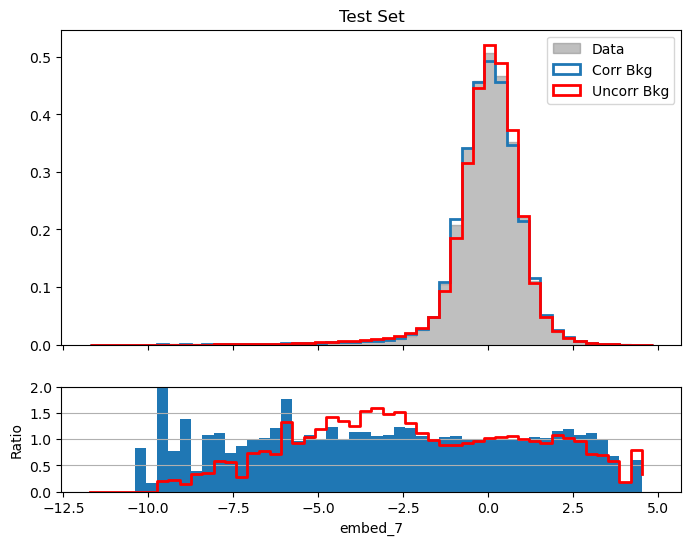

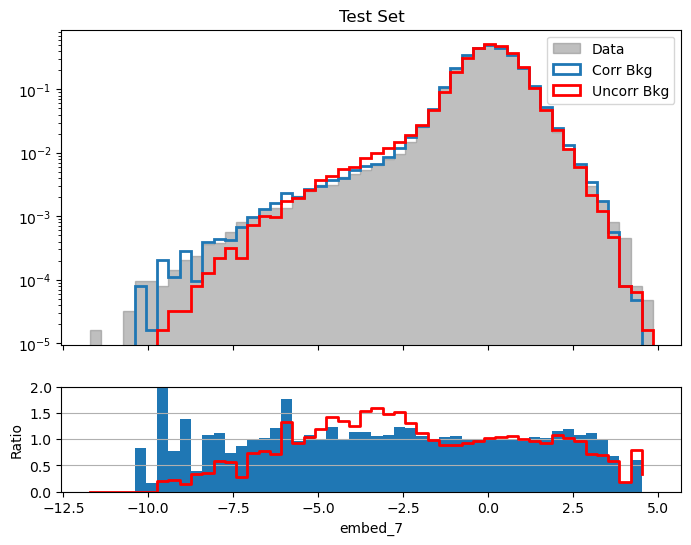

In [52]:
trainer.correctCurrent()
trainer.plotCurrent(50,ylim=[0,2])

# Try running standalone corrections

In [54]:
corrector = qrnn.chainedNFCorrector("NF_models_QR_general/HerwigToPythia_contrastiveSpace_qcd/")

In [62]:
corr_herw_test = corrector.correctFull(herw2_test)
corr_herw_test = np.concatenate([corr_herw_test[v] for v in corrector.varNames],axis=1)

[0]


100%|██████████| 19/19 [00:00<00:00, 27.74it/s]


[0, 1]


100%|██████████| 19/19 [00:00<00:00, 29.53it/s]


[0, 1, 2]


...

100%|██████████| 19/19 [00:00<00:00, 25.76it/s]


[0, 1, 2, 3, 4, 5]


100%|██████████| 19/19 [00:00<00:00, 25.14it/s]


[0, 1, 2, 3, 4, 5, 6]


100%|██████████| 19/19 [00:00<00:00, 26.73it/s]


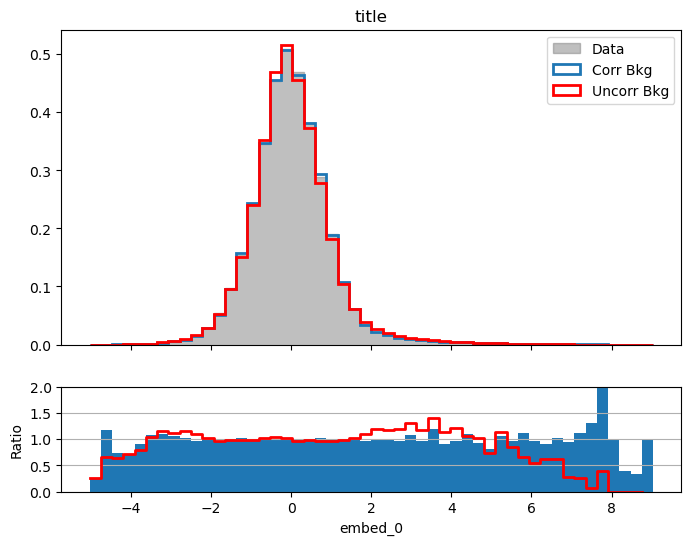

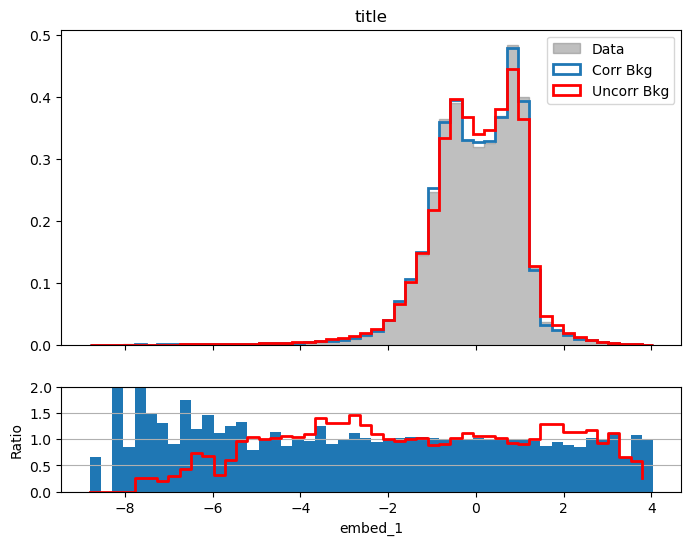

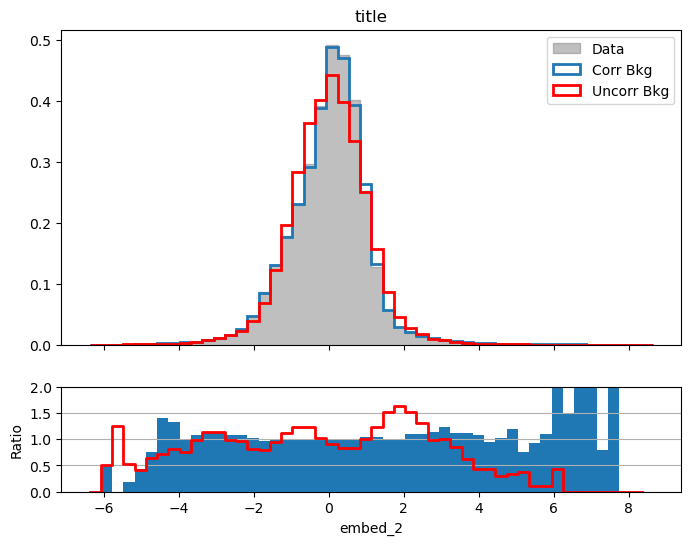

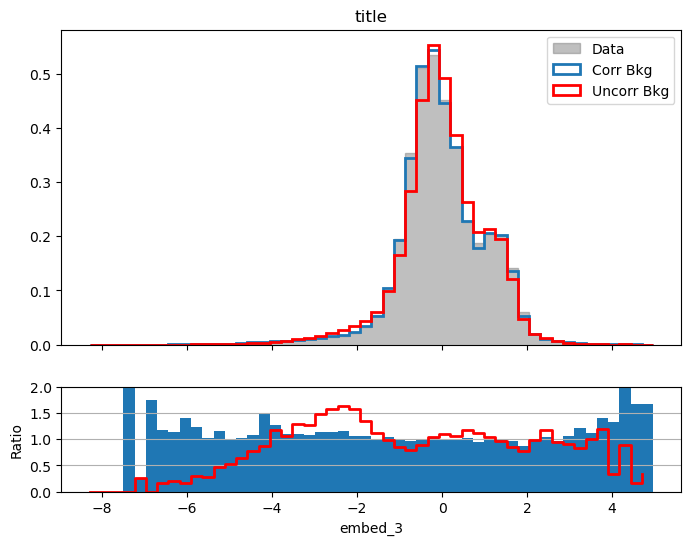

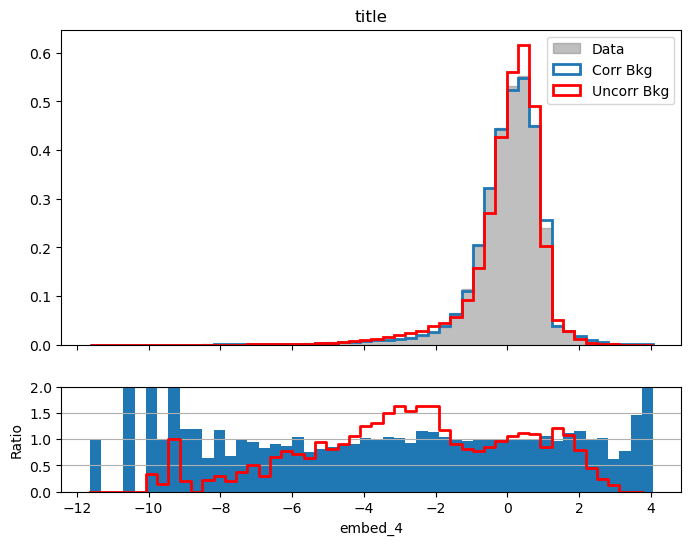

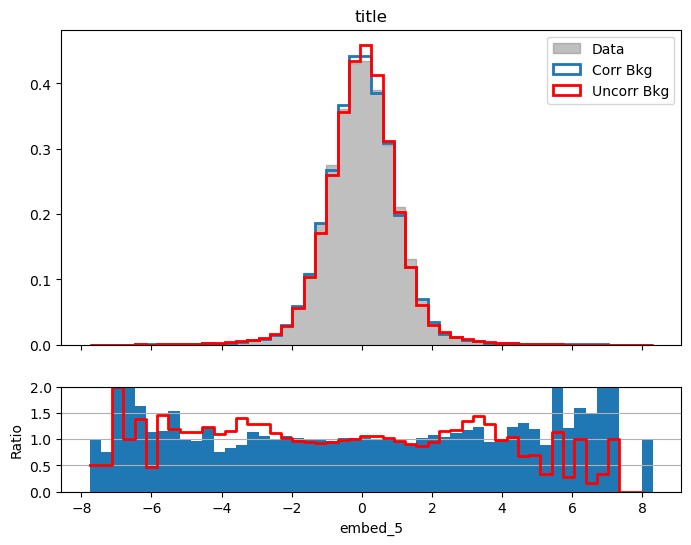

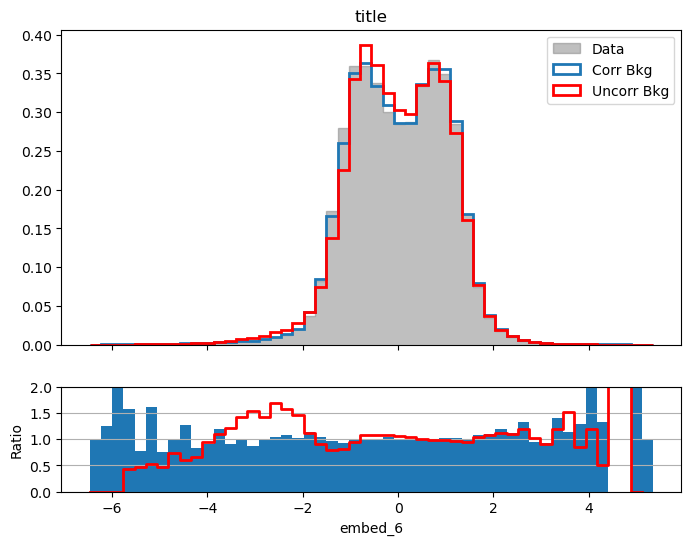

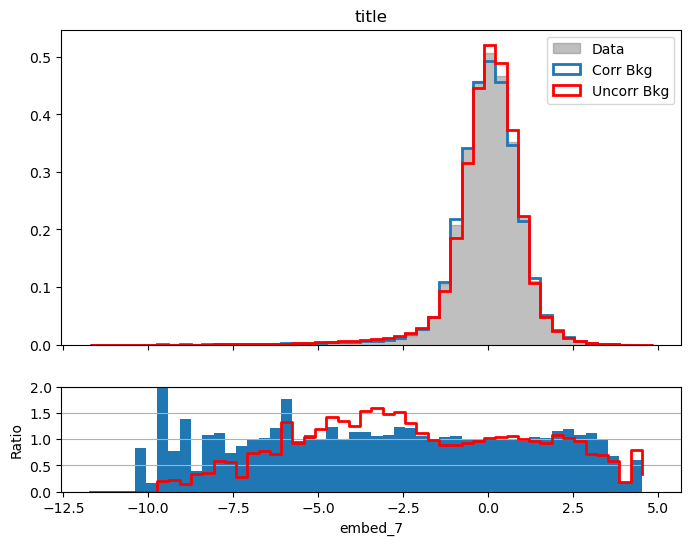

In [63]:
for i in range(pyth_test.shape[1]):
    qrnn.plotTriplet(pyth_test[:,i],corr_herw_test[:,i],herw_test[:,i],50,corrector.varNames[i],'title',"",save=False,log=False,ylim=[0,2])

In [64]:
nn_pyth_train, nn_pyth_test = train_test_split(pyth_test,train_size=0.5,random_state=73714)
nn_pyth_test, nn_pyth_val = train_test_split(nn_pyth_test,train_size=0.7,random_state=14822)

nn_herw_train, nn_herw_test = train_test_split(herw_test,train_size=0.5,random_state=19458)
nn_herw_test, nn_herw_val = train_test_split(nn_herw_test,train_size=0.7,random_state=18854)

nn_corr_herw_train, nn_corr_herw_test = train_test_split(corr_herw_test,train_size=0.5,random_state=62111)
nn_corr_herw_test, nn_corr_herw_val = train_test_split(nn_corr_herw_test,train_size=0.7,random_state=51368)

Loss: 0.4395780563354492, p = 973: 100%|██████████| 7350/7350 [01:44<00:00, 70.27it/s] 


Text(0, 0.5, 'True Negative Rate')

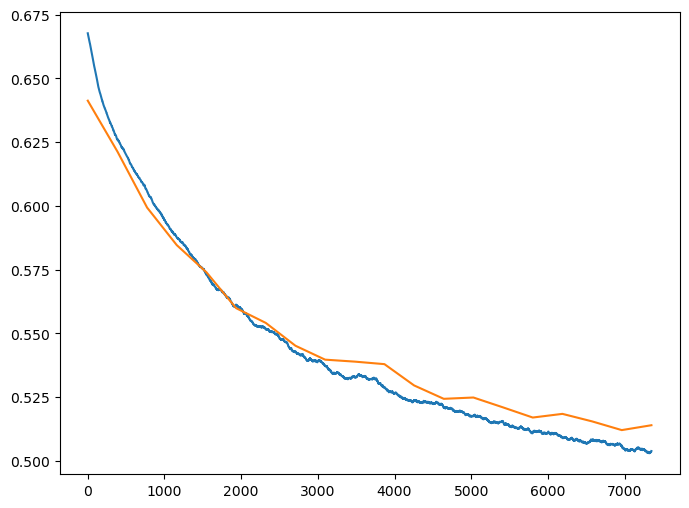

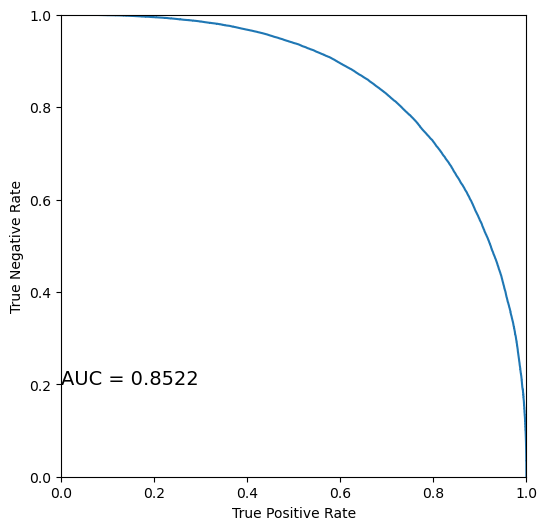

In [67]:
train = np.concatenate((nn_herw_train,nn_pyth_train),axis=0)
train_lab = np.concatenate((np.zeros((nn_herw_train.shape[0],1)),np.ones((nn_pyth_train.shape[0],1))),axis=0)
perm = np.random.permutation(train.shape[0])
train = train[perm]
train_lab = train_lab[perm]

val = np.concatenate((nn_herw_val,nn_pyth_val),axis=0)
val_lab = np.concatenate((np.zeros((nn_herw_val.shape[0],1)),np.ones((nn_pyth_val.shape[0],1))),axis=0)
perm = np.random.permutation(val.shape[0])
val = val[perm]
val_lab = val_lab[perm]

test = np.concatenate((nn_herw_test,nn_pyth_test),axis=0)
test_lab = np.concatenate((np.zeros((nn_herw_test.shape[0],1)),np.ones((nn_pyth_test.shape[0],1))),axis=0)
perm = np.random.permutation(test.shape[0])
test = test[perm]
test_lab = test_lab[perm]


# define and train NN
n_in = train.shape[1]
n_hidden = 64
num_hidden = 6
n_out = 1
act = nn.ReLU()
out_act = nn.Sigmoid()

net1 = qrnn.NeuralNet(n_in, n_hidden, n_out, num_hidden, act=act, out_act=out_act, dropout=0.1)
net1 = qrnn.train_nn(net1,train,train_lab,val,val_lab,n_epoch=20,lr=5e-4,bs=512,lossfunc="BCE")

# save NN
torch.save(net1,"NF_models_QR_general/HerwigToPythia_contrastiveSpace_qcd/NN_Pythia_vs_uncorrHerwig_latentSpace.pt")

# evaluate NN on test set
from sklearn.metrics import roc_auc_score, roc_curve
net1 = net1.to(device)
with torch.no_grad():
    preds = net1(torch.tensor(test,device=device,dtype=torch.float32)).cpu().numpy()
    
fpr,tpr,thresh = roc_curve(test_lab,preds)
auc = roc_auc_score(test_lab,preds)

plt.figure(figsize=(6,6))
plt.plot(tpr,1-fpr,label=r'Pythia')
plt.xlim([0,1])
plt.ylim([0,1])
plt.text(0.0,0.2,f"AUC = {auc:.4f}",fontsize=14)
plt.xlabel("True Positive Rate")
plt.ylabel("True Negative Rate")

Loss: 0.6894934177398682, p = 62: 100%|██████████| 940/940 [03:11<00:00,  4.92it/s]


Text(0, 0.5, 'True Negative Rate')

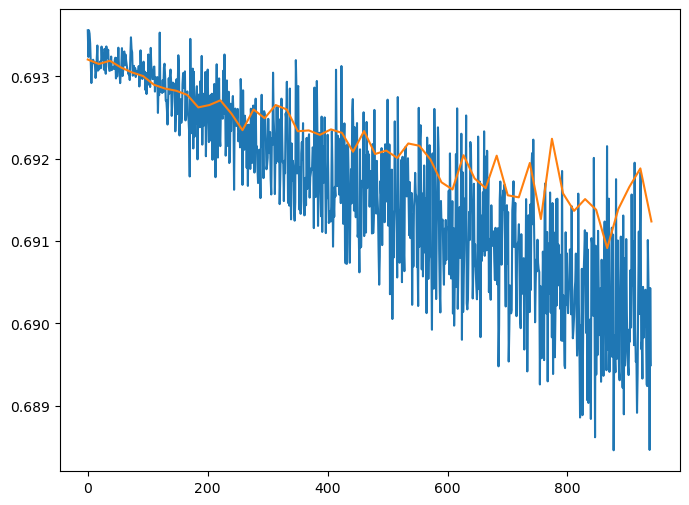

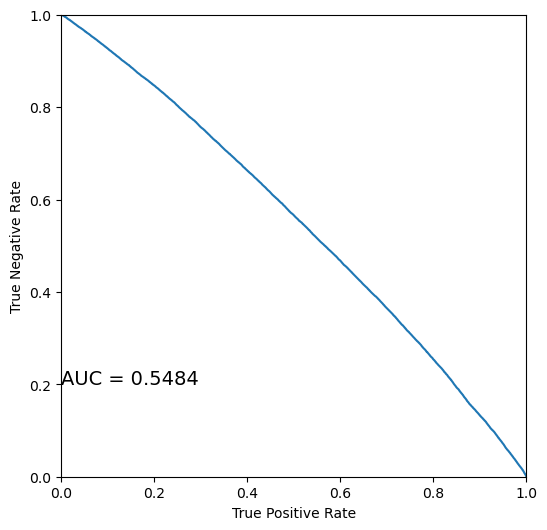

In [73]:
train = np.concatenate((nn_corr_herw_train,nn_pyth_train),axis=0)
train_lab = np.concatenate((np.zeros((nn_corr_herw_train.shape[0],1)),np.ones((nn_pyth_train.shape[0],1))),axis=0)
perm = np.random.permutation(train.shape[0])
train = train[perm]
train_lab = train_lab[perm]

val = np.concatenate((nn_corr_herw_val,nn_pyth_val),axis=0)
val_lab = np.concatenate((np.zeros((nn_corr_herw_val.shape[0],1)),np.ones((nn_pyth_val.shape[0],1))),axis=0)
perm = np.random.permutation(val.shape[0])
val = val[perm]
val_lab = val_lab[perm]

test = np.concatenate((nn_corr_herw_test,nn_pyth_test),axis=0)
test_lab = np.concatenate((np.zeros((nn_corr_herw_test.shape[0],1)),np.ones((nn_pyth_test.shape[0],1))),axis=0)
perm = np.random.permutation(test.shape[0])
test = test[perm]
test_lab = test_lab[perm]


# define and train NN
n_in = train.shape[1]
n_hidden = 64
num_hidden = 6
n_out = 1
act = nn.ReLU()
out_act = nn.Sigmoid()

net1 = qrnn.NeuralNet(n_in, n_hidden, n_out, num_hidden, act=act, out_act=out_act, dropout=0.2)
net1 = qrnn.train_nn(net1,train,train_lab,val,val_lab,n_epoch=50,lr=5e-4,bs=10000,lossfunc="BCE")

# save NN
torch.save(net1,"NF_models_QR_general/HerwigToPythia_contrastiveSpace_qcd/NN_Pythia_vs_corrHerwig_latentSpace.pt")

# evaluate NN on test set
from sklearn.metrics import roc_auc_score, roc_curve
net1 = net1.to(device)
with torch.no_grad():
    preds = net1(torch.tensor(test,device=device,dtype=torch.float32)).cpu().numpy()
    
fpr,tpr,thresh = roc_curve(test_lab,preds)
auc = roc_auc_score(test_lab,preds)

plt.figure(figsize=(6,6))
plt.plot(tpr,1-fpr,label=r'Pythia')
plt.xlim([0,1])
plt.ylim([0,1])
plt.text(0.0,0.2,f"AUC = {auc:.4f}",fontsize=14)
plt.xlabel("True Positive Rate")
plt.ylabel("True Negative Rate")